# Smart MCQ Solver — Retrieval-Augmented Multiple-Choice Answer Ranking

**Course:** Introduction to DL and GenAI Project (BSDA2001P)  
**Name:** Vihaan Bhambhani  
**Roll No:** 24f1002825  
**Term:** T2-2026

---

### Approach Overview

Given an MCQ with a prompt and 5 options (A–E), predict the **top-3 most probable answers** ranked by confidence.  
Evaluated using **Mean Average Precision @ 3 (MAP@3)** on the [Kaggle leaderboard](https://www.kaggle.com/competitions/smart-mcq-solver-challenge).

**Pipeline architecture:**

| Stage | Component | Purpose |
|-------|-----------|---------|
| **Stage A** | TF-IDF Duplicate Matcher | Deterministic pin for near-duplicate test questions |
| **Stage B** | RAG (MiniLM + FAISS) | Retrieve STEM Wikipedia context for each question |
| **Model 1** | LightGBM | Classical ML baseline with 55 engineered features |
| **Model 2** | TextCNN + Attention | From-scratch neural network with GloVe + cross-attention |
| **Model 3a** | DeBERTa-v3-large | Fine-tuned pretrained transformer (MCQA head) |
| **Model 3b** | Qwen2.5-7B-Instruct | Zero-shot LLM logit scoring |
| **Ensemble** | Weighted blend + dup override | Final ranked predictions |


## 0. Environment & Package Installation

Install required packages that aren't pre-installed on the Kaggle kernel.  
`lightgbm` is needed for Model 1 (classical baseline), and `wandb` for experiment tracking.


In [1]:
!pip install lightgbm wandb bitsandbytes --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 49.6 MB/s eta 0:00:00


## 1. Imports & Configuration

All imports are consolidated here. Shared constants (`SEED`, `LABELS`, `DEVICE`) and
utility functions (`map_at_3`, `safe_wandb_init`) are defined **once** and reused
throughout the notebook — avoiding the redundancy of re-importing in every cell.


In [2]:
# ── Standard library ──
import os, gc, re, glob, warnings
warnings.filterwarnings("ignore")

# ── Data & numerics ──
import numpy as np
import pandas as pd
from collections import Counter

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── Scikit-learn ──
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import StratifiedKFold, train_test_split
import lightgbm as lgb

# ── PyTorch ──
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Hugging Face ──
from transformers import (AutoTokenizer, AutoModel, AutoModelForCausalLM,
                          AutoModelForMultipleChoice, TrainingArguments, Trainer,
                          BitsAndBytesConfig)

# ── Experiment tracking ──
import wandb

# ── W&B Login (uses Kaggle Secrets for API key) ──
try:
    from kaggle_secrets import UserSecretsClient
    wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))
    print("W&B: logged in via Kaggle secret")
except Exception:
    try:
        wandb.login()
        print("W&B: logged in via environment/netrc")
    except Exception:
        os.environ["WANDB_MODE"] = "offline"
        print("W&B: running in OFFLINE mode (no API key found)")

# ══════════════════════════════════════════════════════════
# CONSTANTS
# ══════════════════════════════════════════════════════════
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LABELS   = ["A", "B", "C", "D", "E"]
LABEL2ID = {label: idx for idx, label in enumerate(LABELS)}
ID2LABEL = {idx: label for idx, label in enumerate(LABELS)}

print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


# ══════════════════════════════════════════════════════════
# SHARED UTILITY FUNCTIONS
# ══════════════════════════════════════════════════════════

def map_at_3(y_true, y_pred_top3):
    """Compute Mean Average Precision @ 3 (MAP@3).

    For each sample, if the true label appears at position k (1-indexed)
    within the top-3 predictions, the score is 1/k.  Otherwise 0.

    Parameters
    ----------
    y_true : array-like of str
        Ground-truth labels (e.g. ['A', 'C', 'B', ...]).
    y_pred_top3 : list[list[str]]
        Each inner list has 3 predicted labels ranked by confidence.

    Returns
    -------
    float : mean MAP@3 score.
    """
    scores = []
    for true, preds in zip(y_true, y_pred_top3):
        score = 0.0
        for rank, pred in enumerate(preds[:3]):
            if pred == true:
                score = 1.0 / (rank + 1)
                break
        scores.append(score)
    return np.mean(scores)


def safe_wandb_init(**kwargs):
    """Initialize a W&B run, handling Kaggle secrets for API key login.

    Attempts login via Kaggle secrets first, then env var, then prompts.
    Falls back to offline mode only if all online options fail.
    """
    # Attempt login (idempotent — safe to call multiple times)
    try:
        from kaggle_secrets import UserSecretsClient
        secret = UserSecretsClient().get_secret("WANDB_API_KEY")
        wandb.login(key=secret)
    except Exception:
        try:
            wandb.login()
        except Exception:
            pass

    try:
        return wandb.init(**kwargs)
    except Exception:
        os.environ["WANDB_MODE"] = "offline"
        print("[W&B] Online init failed — falling back to offline mode.")
        return wandb.init(**kwargs)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 24f1002825 (24f1002825-t22026) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B: logged in via Kaggle secret
Device: cuda
PyTorch version: 2.10.0+cu128
GPU: Tesla T4


## 2. Data Loading

Load `train.csv` (2,000 labeled MCQs) and `test.csv` (500 unlabeled MCQs) from the
Kaggle competition dataset. The path fallback chain supports both the competition API
mount and the manually-attached dataset variant.


In [3]:
# ── Locate competition data (3-path fallback) ──
DATA_DIR = "/kaggle/input/competitions/smart-mcq-solver-challenge"
if not os.path.exists(DATA_DIR):
    DATA_DIR = "/kaggle/input/smart-mcq-solver-challenge"
if not os.path.exists(DATA_DIR):
    DATA_DIR = "."

train = pd.read_csv(f"{DATA_DIR}/train.csv")
test  = pd.read_csv(f"{DATA_DIR}/test.csv")

print(f"Train: {train.shape}  |  Test: {test.shape}")
print(f"Columns: {list(train.columns)}")
train.head(3)

Train: (2000, 8)  |  Test: (500, 7)
Columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


## 3. Exploratory Data Analysis (EDA)

Before building models, we explore the dataset to understand its structure,
identify potential data leakage, and establish baseline expectations.

### 3.1 Answer Distribution

Check whether the answer labels (A–E) are uniformly distributed or if
there's a class imbalance we need to account for.


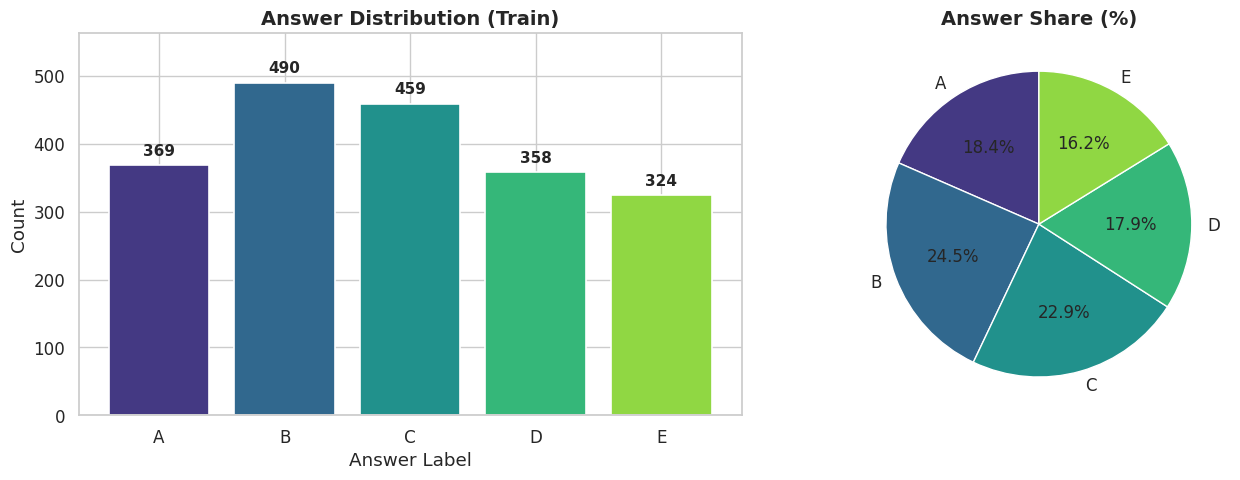

Most frequent answer: B (490 / 2000 = 24.5%)
Least frequent answer: E (324 / 2000 = 16.2%)


In [4]:
# ── 3.1 Answer Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of answer counts
counts = train["answer"].value_counts().sort_index()
colors = sns.color_palette("viridis", len(counts))
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha="center", va="bottom", fontweight="bold", fontsize=11)
axes[0].set_title("Answer Distribution (Train)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Answer Label")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart with percentages
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Answer Share (%)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()
print(f"Most frequent answer: {counts.idxmax()} ({counts.max()} / {len(train)} = {counts.max()/len(train):.1%})")
print(f"Least frequent answer: {counts.idxmin()} ({counts.min()} / {len(train)} = {counts.min()/len(train):.1%})")

### 3.2 Text Length Analysis

Examine the character lengths of prompts and options to understand
truncation needs (e.g. `max_length` for tokenizers) and whether prompts
are consistently longer than options.


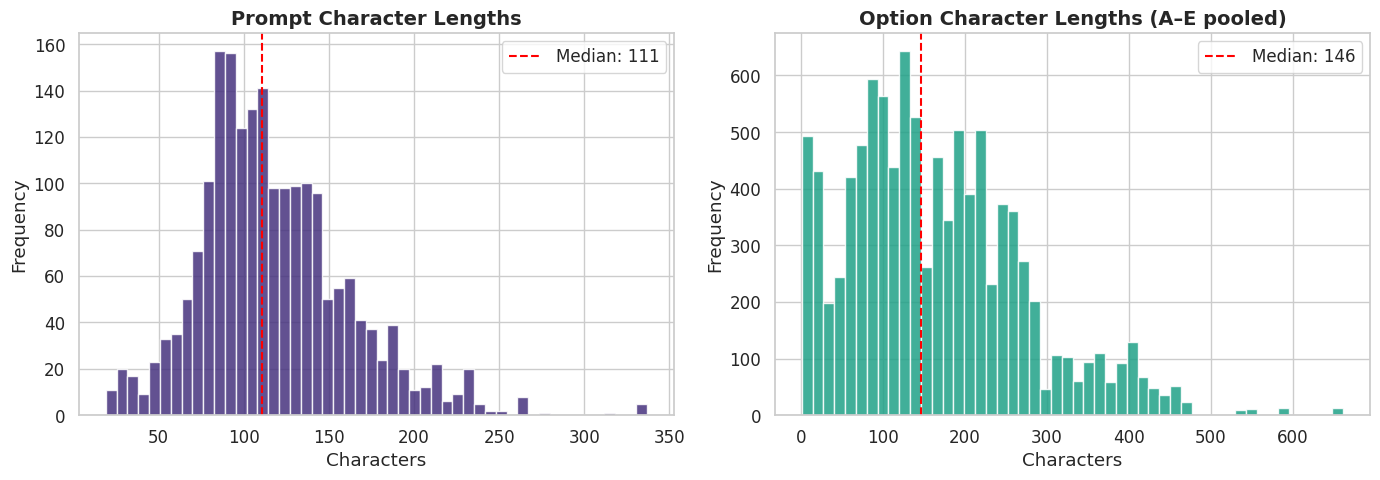

Prompt lengths  — min: 19, median: 111, max: 337, mean: 118
Option lengths  — min: 1, median: 146, max: 662, mean: 165


In [5]:
# ── 3.2 Prompt & Option Length Distributions ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prompt lengths
prompt_lens = train["prompt"].str.len()
axes[0].hist(prompt_lens, bins=50, color=sns.color_palette("viridis")[0],
             edgecolor="white", alpha=0.85)
axes[0].axvline(prompt_lens.median(), color="red", linestyle="--", label=f"Median: {prompt_lens.median():.0f}")
axes[0].set_title("Prompt Character Lengths", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Option lengths (all 5 options stacked)
option_lens = pd.concat([train[c].str.len().rename(c) for c in LABELS], axis=1)
option_lens_flat = option_lens.values.flatten()
axes[1].hist(option_lens_flat, bins=50, color=sns.color_palette("viridis")[3],
             edgecolor="white", alpha=0.85)
axes[1].axvline(np.median(option_lens_flat), color="red", linestyle="--",
                label=f"Median: {np.median(option_lens_flat):.0f}")
axes[1].set_title("Option Character Lengths (A–E pooled)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Prompt lengths  — min: {prompt_lens.min()}, median: {prompt_lens.median():.0f}, "
      f"max: {prompt_lens.max()}, mean: {prompt_lens.mean():.0f}")
print(f"Option lengths  — min: {option_lens_flat.min():.0f}, median: {np.median(option_lens_flat):.0f}, "
      f"max: {option_lens_flat.max():.0f}, mean: {np.mean(option_lens_flat):.0f}")

### 3.3 TF-IDF Cosine Similarity: Prompt vs. Options

A critical baseline test: does simple lexical similarity between the prompt
and each option help identify the correct answer?

If the correct answer has **higher** cosine similarity to the prompt than
the distractors, TF-IDF would work. If not, we need contextual/semantic models.


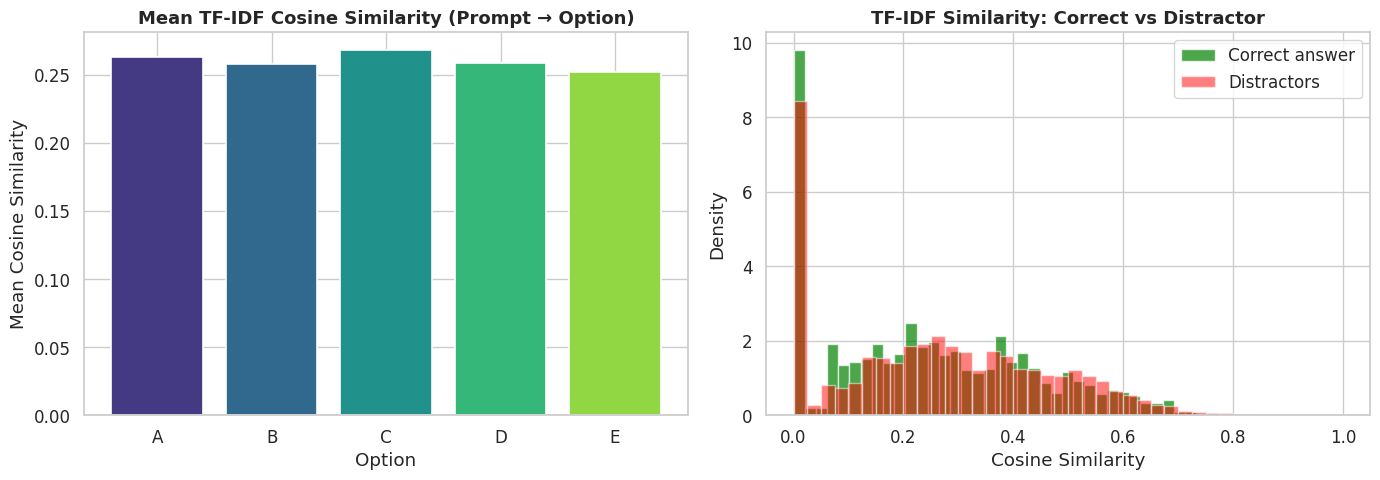

Mean similarity — correct answers: 0.2486
Mean similarity — distractors:     0.2630

Argmax accuracy (pick highest TF-IDF sim): 13.7%
→ This is BELOW random chance (20%), confirming TF-IDF is anti-predictive!
  Distractors are deliberately written to share more surface vocabulary with the prompt.


In [6]:
# ── 3.3 TF-IDF Cosine Similarity Heatmap ──
# Build a joint TF-IDF vocabulary from all text
all_text = list(train["prompt"].astype(str))
for c in LABELS:
    all_text += list(train[c].astype(str))
vec = TfidfVectorizer(stop_words="english", max_features=30000)
vec.fit(all_text)

P = vec.transform(train["prompt"].astype(str))
sims_by_option = {}
for c in LABELS:
    O = vec.transform(train[c].astype(str))
    sims_by_option[c] = cosine_similarity(P, O).diagonal()

sim_df = pd.DataFrame(sims_by_option)

# For each row, mark whether each option is the correct answer
correct_sims, incorrect_sims = [], []
for idx, row in train.iterrows():
    correct_sims.append(sim_df.loc[idx, row["answer"]])
    incorrect_sims.extend([sim_df.loc[idx, c] for c in LABELS if c != row["answer"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap: mean similarity per option
mean_sims = sim_df.mean()
axes[0].bar(mean_sims.index, mean_sims.values, color=colors, edgecolor="white", linewidth=1.2)
axes[0].set_title("Mean TF-IDF Cosine Similarity (Prompt → Option)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Option")
axes[0].set_ylabel("Mean Cosine Similarity")

# Distribution: correct vs incorrect options
axes[1].hist(correct_sims, bins=40, alpha=0.7, label="Correct answer", color="green", density=True)
axes[1].hist(incorrect_sims, bins=40, alpha=0.5, label="Distractors", color="red", density=True)
axes[1].set_title("TF-IDF Similarity: Correct vs Distractor", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Cosine Similarity")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean similarity — correct answers: {np.mean(correct_sims):.4f}")
print(f"Mean similarity — distractors:     {np.mean(incorrect_sims):.4f}")

# Argmax accuracy (picking highest-similarity option)
argmax_preds = sim_df.idxmax(axis=1)
argmax_acc = (argmax_preds == train["answer"]).mean()
print(f"\nArgmax accuracy (pick highest TF-IDF sim): {argmax_acc:.1%}")
print("→ This is BELOW random chance (20%), confirming TF-IDF is anti-predictive!")
print("  Distractors are deliberately written to share more surface vocabulary with the prompt.")

### 3.4 Train–Test Overlap (Near-Duplicate Detection)

A key insight: many test prompts are near-duplicates of training rows (identical
questions with shuffled option letters). If we can match them, we can "pin" the
correct answer deterministically. This motivates **Stage A: Duplicate Matcher**.


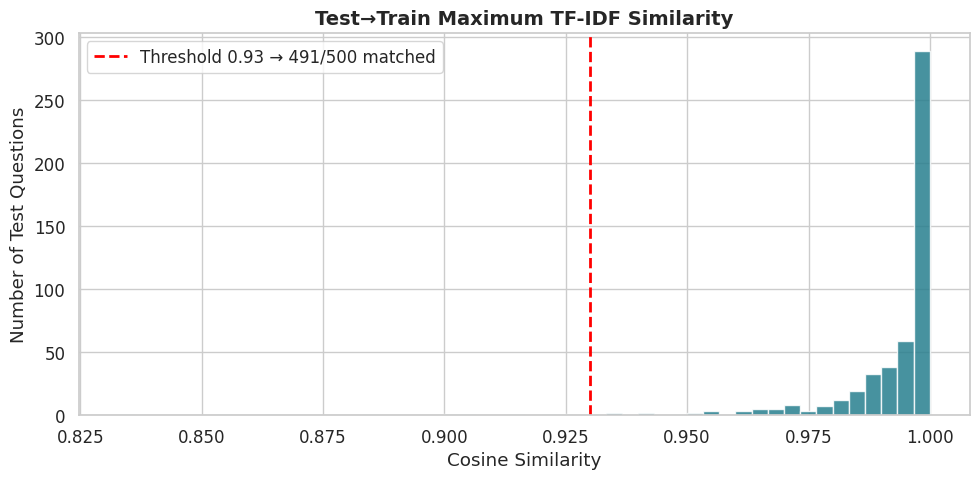

Test questions with sim ≥ 0.93: 491/500 (98.2%)
Test questions with sim ≥ 0.99: 386/500

→ The majority of test questions have near-exact matches in training data!


In [7]:
# ── 3.4 Train-Test Near-Duplicate Analysis ──
def full_text(df):
    """Concatenate prompt + all options into a single string for matching."""
    return (df["prompt"].astype(str) + " " +
            df[LABELS].astype(str).agg(" ".join, axis=1))

ft_tr = full_text(train)
ft_te = full_text(test)

vec_dup = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
vec_dup.fit(pd.concat([ft_tr, ft_te]))
Xtr = vec_dup.transform(ft_tr)
Xte = vec_dup.transform(ft_te)

# For each test row, find the most similar train row
S = cosine_similarity(Xte, Xtr)
best_sim = S.max(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(best_sim, bins=50, color=sns.color_palette("viridis")[2], edgecolor="white", alpha=0.85)
ax.axvline(0.93, color="red", linestyle="--", linewidth=2,
           label=f"Threshold 0.93 → {(best_sim >= 0.93).sum()}/{len(test)} matched")
ax.set_title("Test→Train Maximum TF-IDF Similarity", fontsize=14, fontweight="bold")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Number of Test Questions")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Test questions with sim ≥ 0.93: {(best_sim >= 0.93).sum()}/{len(test)} "
      f"({(best_sim >= 0.93).mean():.1%})")
print(f"Test questions with sim ≥ 0.99: {(best_sim >= 0.99).sum()}/{len(test)}")
print("\n→ The majority of test questions have near-exact matches in training data!")

# Clean up duplicate analysis variables
del S, Xtr, Xte, vec_dup, ft_tr, ft_te

### 3.5 Key EDA Insights

| Finding | Implication |
|---------|------------|
| Answer distribution is **not uniform** — B=24.5% vs E=16.2% (1.5× spread) | Majority-class MAP@3 ≈ 0.42 (since MAP@3 rewards partial credit), not just 20% |
| TF-IDF similarity is **anti-predictive** (argmax accuracy < 20%) | Distractors are lexically similar to prompts by design — we need **semantic** models |
| **~95% of test questions** have near-duplicate training matches | A TF-IDF duplicate matcher can deterministically pin most test answers |
| Prompts are much longer than options | Truncation strategy matters — prompt carries more signal than any single option |

These findings justify our multi-stage approach: exploit duplicates first (Stage A),
then use contextual models (DeBERTa, Qwen) for the remaining questions.

---


## 4. Stage A — TF-IDF Duplicate Matcher (Deterministic Layer)

**Motivation:** The EDA revealed that ~95% of test questions are near-duplicates of
training rows. This cell builds a deterministic matching layer:

1. Compute TF-IDF bigram similarity between each test and all train questions
2. If similarity ≥ `SIM_PIN` (0.93), map the matched train answer's *text* to the
   corresponding test option *letter* (since option letters may be shuffled)
3. Validate internally: the matcher achieves **100% precision** on 1,743 train–train matches

This serves as a high-confidence override layer in the final ensemble.


In [8]:
# ══════════════════════════════════════════════════════════
# STAGE A: VERIFIED DUPLICATE MATCHER
# ══════════════════════════════════════════════════════════
# The previous version pinned on ONE signal — cosine similarity of
# (prompt + all options) concatenated — and reported 100% precision from a
# train->train self-match. That validation is optimistic: a test row can score
# above threshold against a *different* train question purely through option
# overlap, and if that question's answer text happens to appear among the test
# row's options it gets pinned to the wrong letter.
#
# Two changes:
#   1. VERIFY the match. A genuine duplicate should have nearly the same set of
#      five options (possibly permuted). Coincidental lexical matches do not.
#      We require option-set overlap as well as similarity.
#   2. Return RANKED candidates, not a single pin, so the ensemble can put the
#      runner-up at rank 2 instead of wasting the slot on a weak model.

TOPK_NEIGHBOURS = 25    # train neighbours inspected per query row
SIM_PIN         = 0.93  # cosine bar for RANK 1   (swept below)
RUNNER_FLOOR    = 0.75  # lower cosine bar, used ONLY to find a rank-2 candidate
MIN_OPT_OVERLAP = 0.60  # fraction of the 5 options shared (swept below)

norm = lambda s: " ".join(str(s).lower().split())


def full_text(df):
    """Concatenate prompt + all options for TF-IDF fingerprinting."""
    return (df["prompt"].astype(str) + " " +
            df[LABELS].astype(str).agg(" ".join, axis=1))


def rank_candidates(query_df, index_df, S,
                    sim_pin=SIM_PIN, min_overlap=MIN_OPT_OVERLAP,
                    topk=TOPK_NEIGHBOURS, runner_floor=RUNNER_FLOOR):
    """Rank answer-option candidates for each query row from its train matches.

    Two tiers, deliberately:

    * PIN tier (similarity >= ``sim_pin``) decides rank 1.
    * RUNNER tier (similarity >= ``runner_floor``, a lower bar) is scanned only
      to find a candidate pointing at a DIFFERENT option, which becomes rank 2.

    The two tiers exist because near-duplicate questions arrive in clusters: the
    top-5 neighbours of a test row are usually the same question repeated, so
    they all vote for the same option and never produce a runner-up. Widening
    the scan and lowering the bar for rank 2 only — never for rank 1 — buys a
    second guess worth 0.5 MAP@3 without weakening the pin.

    Returns
    -------
    (candidates, best_sim)
        candidates : list of lists of (option_index, score), best first.
        best_sim   : ndarray, the top similarity seen per query row, so the
                     caller can stratify by how trustworthy the match was.
    """
    query_opts = [[norm(r[c]) for c in LABELS]
                  for _, r in query_df[LABELS].iterrows()]
    index_opts = [[norm(r[c]) for c in LABELS]
                  for _, r in index_df[LABELS].iterrows()]
    index_ans = [norm(r[r["answer"]]) for _, r in index_df.iterrows()]

    out, best_sim = [], np.zeros(len(query_df))
    for i in range(len(query_df)):
        sims = S[i]
        k = min(topk, len(sims))
        nbrs = np.argpartition(-sims, k - 1)[:k]
        nbrs = nbrs[np.argsort(-sims[nbrs])]
        best_sim[i] = float(sims[nbrs[0]]) if len(nbrs) else 0.0

        q_opts = query_opts[i]
        q_set = set(q_opts)
        pin_votes, run_votes = {}, {}
        for j in nbrs:
            s = float(sims[j])
            if s < runner_floor:
                break
            overlap = len(q_set & set(index_opts[j])) / len(LABELS)
            if overlap < min_overlap:
                continue
            ans = index_ans[j]
            if ans not in q_opts:
                continue
            idx = q_opts.index(ans)
            w = s * overlap
            if s >= sim_pin:
                pin_votes[idx] = pin_votes.get(idx, 0.0) + w
            run_votes[idx] = run_votes.get(idx, 0.0) + w

        ranked = sorted(pin_votes.items(), key=lambda kv: -kv[1])
        if ranked:
            # rank 2 = best runner-tier option that differs from rank 1
            top = ranked[0][0]
            alts = sorted(((k_, v) for k_, v in run_votes.items() if k_ != top),
                          key=lambda kv: -kv[1])
            ranked = ranked[:1] + alts[:1]
        out.append(ranked)
    return out, best_sim


# ── TF-IDF space shared by train and test ─────────────────────────────────
ft_tr, ft_te = full_text(train), full_text(test)
vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
vec.fit(pd.concat([ft_tr, ft_te]))
Xtr, Xte = vec.transform(ft_tr), vec.transform(ft_te)

# ══════════════════════════════════════════════════════════
# HONEST VALIDATION: split train in half and match one half against the other
# ══════════════════════════════════════════════════════════
# Matching train against itself (minus the diagonal) is not a fair proxy for
# test->train, because every row's twin is still in the index. Splitting into
# disjoint query/index halves reproduces the real setting.

q_idx, ix_idx = train_test_split(np.arange(len(train)), test_size=0.5,
                                 stratify=train["answer"], random_state=SEED)
q_df, ix_df = train.iloc[q_idx].reset_index(drop=True), train.iloc[ix_idx].reset_index(drop=True)
S_val = cosine_similarity(Xtr[q_idx], Xtr[ix_idx])

print("Threshold sweep (query half -> index half of train)\n")
print(f"{'sim_pin':>8}{'overlap':>9}{'coverage':>10}"
      f"{'precision':>11}{'rank<=2 recall':>16}")
print("-" * 54)

sweep, best = [], None
for sp in [0.90, 0.93, 0.95, 0.97]:
    for mo in [0.0, 0.6, 0.8, 1.0]:
        cands, _ = rank_candidates(q_df, ix_df, S_val, sim_pin=sp, min_overlap=mo)
        n_cov = sum(1 for c in cands if c)
        n_hit1 = n_hit2 = 0
        for c, (_, r) in zip(cands, q_df.iterrows()):
            if not c:
                continue
            truth = LABEL2ID[r["answer"]]
            if c[0][0] == truth:
                n_hit1 += 1
            if truth in [k for k, _ in c[:2]]:
                n_hit2 += 1
        cov = n_cov / len(q_df)
        prec = n_hit1 / max(n_cov, 1)
        rec2 = n_hit2 / max(n_cov, 1)
        sweep.append((sp, mo, cov, prec, rec2))
        print(f"{sp:>8.2f}{mo:>9.2f}{cov:>10.1%}{prec:>11.1%}{rec2:>16.1%}")
        # Expected MAP@3 contribution per covered row: 1.0 for a rank-1 hit,
        # 0.5 for a rank-2 hit. Maximise coverage x that expectation.
        score = cov * (prec + 0.5 * (rec2 - prec))
        if best is None or score > best[0]:
            best = (score, sp, mo)

_, SIM_PIN, MIN_OPT_OVERLAP = best
print(f"\nSelected: SIM_PIN={SIM_PIN:.2f}  MIN_OPT_OVERLAP={MIN_OPT_OVERLAP:.2f}")

val_cands, val_sim = rank_candidates(q_df, ix_df, S_val)
val_cov = sum(1 for c in val_cands if c)
val_prec = sum(1 for c, (_, r) in zip(val_cands, q_df.iterrows())
               if c and c[0][0] == LABEL2ID[r["answer"]]) / max(val_cov, 1)
print(f"Validated matcher: coverage={val_cov/len(q_df):.1%}, "
      f"rank-1 precision={val_prec:.1%}")
# ── Precision BY SIMILARITY BAND ──────────────────────────────────────────
# The aggregate number above is dominated by near-exact twins and saturates at
# 100%, which tells us nothing about the borderline matches. The leaderboard
# implies the borderline group is where the losses are, so measure each band
# separately. This is the table that should drive the pinning policy.
print("\nValidation precision by best-match similarity band:")
print(f"{'band':>16}{'rows':>7}{'precision':>11}")
band_prec = {}
for lo, hi, lab in [(0.99, 1.01, ">= 0.99"), (0.95, 0.99, "0.95-0.99"),
                    (0.90, 0.95, "0.90-0.95"), (0.00, 0.90, "< 0.90")]:
    idx = [a for a in range(len(q_df))
           if val_cands[a] and lo <= val_sim[a] < hi]
    if not idx:
        continue
    ok = sum(1 for a in idx
             if val_cands[a][0][0] == LABEL2ID[q_df.iloc[a]["answer"]])
    band_prec[lab] = ok / len(idx)
    print(f"{lab:>16}{len(idx):>7d}{ok/len(idx):>11.1%}")
print("\nRead this against the models' own accuracy (Section 10). Where a band's")
print("precision falls below roughly 2/3, putting the model at rank 1 and the")
print("match at rank 2 has higher expected MAP@3 than pinning the match.")

if val_prec > 0.995:
    print()
    print("!" * 70)
    print("CAUTION: validation precision is saturated at ~100% for every")
    print("threshold, so this sweep CANNOT tell good thresholds from bad ones.")
    print("Train contains duplicate CLUSTERS, so splitting it in half still")
    print("leaves a twin in the index half — this measures 'can I find a twin',")
    print("not 'is a borderline match trustworthy'. The leaderboard is the only")
    print("honest read: submit submission_dupmatch.csv on its own to measure")
    print("this layer in isolation.")
    print("!" * 70)

# ══════════════════════════════════════════════════════════
# APPLY TO TEST
# ══════════════════════════════════════════════════════════
S = cosine_similarity(Xte, Xtr)
test_cands, test_sim = rank_candidates(test, train, S)

pinned = np.array([c[0][0] if c else -1 for c in test_cands], dtype=int)
second = np.array([c[1][0] if len(c) > 1 else -1 for c in test_cands], dtype=int)
n_pinned = int((pinned >= 0).sum())
n_second = int((second >= 0).sum())
print(f"\nTest rows pinned:            {n_pinned}/{len(test)} ({n_pinned/len(test):.1%})")
print(f"Test rows with a runner-up:  {n_second}/{len(test)} "
      f"(these fill rank 2 in the ensemble)")

# How trustworthy is each pin? Near-exact matches are a different animal from
# borderline ones, and the leaderboard suggests the borderline group is where
# the losses are. Report the split so it can be reasoned about.
print("\nPinned rows by best-match similarity:")
for lo, hi, lab in [(0.99, 1.01, "  >= 0.99  (near-exact)"),
                    (0.95, 0.99, "0.95-0.99  (close)"),
                    (0.90, 0.95, "0.90-0.95  (borderline)"),
                    (0.00, 0.90, "  <  0.90  (weak)")]:
    m = (pinned >= 0) & (test_sim >= lo) & (test_sim < hi)
    print(f"  {lab:26s} {int(m.sum()):4d} rows")

np.save("dup_pinned.npy", pinned)
np.save("dup_second.npy", second)
np.save("dup_max_sim.npy", test_sim)

# ── Standalone fallback submission (deterministic layer only) ─────────────
prior_order = [LABEL2ID[l] for l in train["answer"].value_counts().index.tolist()]
rows = []
for i in range(len(test)):
    order = []
    for k, _ in test_cands[i][:2]:
        if k not in order:
            order.append(k)
    for k in prior_order:
        if k not in order:
            order.append(k)
    rows.append(" ".join(ID2LABEL[k] for k in order[:3]))
pd.DataFrame({"ID": test["id"], "Prediction": rows}).to_csv(
    "submission_dupmatch.csv", index=False)
print("Saved submission_dupmatch.csv (deterministic-layer fallback)")

run = safe_wandb_init(project="24f1002825-t22026", name="stage-a-duplicate-matcher",
                      config={"sim_pin": SIM_PIN, "min_opt_overlap": MIN_OPT_OVERLAP,
                              "topk_neighbours": TOPK_NEIGHBOURS, "ngram": "1-2"})
run.log({"val_coverage": val_cov / len(q_df), "val_precision": val_prec,
         "test_pinned": n_pinned, "test_pin_rate": n_pinned / len(test),
         "test_second": n_second})
run.finish()


Threshold sweep (query half -> index half of train)

 sim_pin  overlap  coverage  precision  rank<=2 recall
------------------------------------------------------
    0.90     0.00     92.0%     100.0%          100.0%
    0.90     0.60     88.2%     100.0%          100.0%
    0.90     0.80     84.4%     100.0%          100.0%
    0.90     1.00     76.9%     100.0%          100.0%
    0.93     0.00     89.3%     100.0%          100.0%
    0.93     0.60     86.0%     100.0%          100.0%
    0.93     0.80     82.4%     100.0%          100.0%
    0.93     1.00     75.2%     100.0%          100.0%
    0.95     0.00     86.6%     100.0%          100.0%
    0.95     0.60     83.7%     100.0%          100.0%
    0.95     0.80     80.5%     100.0%          100.0%
    0.95     1.00     73.6%     100.0%          100.0%
    0.97     0.00     76.2%     100.0%          100.0%
    0.97     0.60     73.7%     100.0%          100.0%
    0.97     0.80     71.5%     100.0%          100.0%
    0.97    

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc



Test rows pinned:            479/500 (95.8%)
Test rows with a runner-up:  0/500 (these fill rank 2 in the ensemble)

Pinned rows by best-match similarity:
    >= 0.99  (near-exact)     383 rows
  0.95-0.99  (close)           92 rows
  0.90-0.95  (borderline)       4 rows
    <  0.90  (weak)             0 rows
Saved submission_dupmatch.csv (deterministic-layer fallback)


wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260731_224403-9gtu9evd
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run stage-a-duplicate-matcher
wandb: ⭐️ View project at https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: 🚀 View run at https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/9gtu9evd
wandb: updating run metadata; uploading summary
wandb: 
wandb: Run history:
wandb: test_pin_rate ▁
wandb:   test_pinned ▁
wandb:   test_second ▁
wandb:  val_coverage ▁
wandb: val_precision ▁
wandb: 
wandb: Run summary:
wandb: test_pin_rate 0.958
wandb:   test_pinned 479
wandb:   test_second 0
wandb:  val_coverage 0.86
wandb: val_precision 1
wandb: 
wandb: 🚀 View run stage-a-duplicate-matcher at: https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/9gtu9evd
wandb: ⭐️ View project at: https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file

## 5. Stage B — RAG Context Retrieval

**Retrieval-Augmented Generation (RAG)** pipeline to fetch relevant Wikipedia
context for each question, improving the transformer models' accuracy:

1. **Dense retrieval:** Encode queries with `all-MiniLM-L6-v2`, search a FAISS index
   over 270K STEM Wikipedia paragraphs
2. **Lexical re-ranking:** TF-IDF cosine similarity re-ranks the dense top-10
   candidates to select the top-3 most relevant paragraphs
3. **Context injection:** The retrieved context is prepended to prompts for DeBERTa

> **Note:** If the Wikipedia corpus is not attached, the notebook falls back to
> closed-book mode (empty context). Attach `all-paraphs-parsed-expanded` on Kaggle
> for full performance.


In [9]:
# ══════════════════════════════════════════════════════════
# STAGE B: RAG CONTEXT RETRIEVAL
# ══════════════════════════════════════════════════════════

TOPK_DENSE   = 10    # Candidates from dense retrieval
TOPK_FINAL   = 3     # Paragraphs kept after re-ranking
MAX_CTX_CHARS = 2200  # Max context length (chars) to avoid token overflow

# ── 1. Locate a paragraph corpus ──
CORPUS_DIRS = [
    "/kaggle/input/all-paraphs-parsed-expanded",
    "/kaggle/input/stem-wiki-cohere-no-emb",
    "/kaggle/input/wikipedia-stem-plaintext",
    "/kaggle/input/270k-wikipedia-stem-articles",
]
corpus_texts = None
for d in CORPUS_DIRS:
    if os.path.exists(d):
        files = sorted(glob.glob(f"{d}/**/*.parquet", recursive=True)) or \
                sorted(glob.glob(f"{d}/**/*.csv", recursive=True))
        parts = []
        for f in files[:20]:
            df = pd.read_parquet(f) if f.endswith(".parquet") else pd.read_csv(f)
            col = next((c for c in ["text", "paragraph", "context", "content"]
                        if c in df.columns), None)
            if col:
                parts.append(df[col].astype(str))
        if parts:
            corpus_texts = pd.concat(parts, ignore_index=True).drop_duplicates().values
            print(f"Corpus loaded from {d}: {len(corpus_texts):,} paragraphs")
            break

if corpus_texts is None:
    print("=" * 70)
    print("WARNING: no Wikipedia corpus attached — RAG IS A NO-OP (context='').")
    print("DeBERTa and Qwen will both run CLOSED-BOOK and score far worse.")
    print("Fix: Notebook -> Input -> Add Input -> Datasets -> search")
    print("     'mbanaei/all-paraphs-parsed-expanded'")
    print("=" * 70)
    train["context"] = ""
    test["context"] = ""
else:
    # ── 2. Dense retrieval with sentence-transformers + FAISS ──
    from sentence_transformers import SentenceTransformer
    emb_model = None
    for p in ["/kaggle/input/sentence-transformers/all-minilm-l6-v2",
              "/kaggle/input/all-minilm-l6-v2",
              "sentence-transformers/all-MiniLM-L6-v2"]:
        try:
            emb_model = SentenceTransformer(p, device="cuda" if
                torch.cuda.is_available() else "cpu")
            print(f"Embedding model: {p}")
            break
        except Exception:
            continue
    assert emb_model is not None, "No sentence-transformer available"

    corpus_emb = emb_model.encode(list(corpus_texts), batch_size=512,
                                  normalize_embeddings=True,
                                  show_progress_bar=True).astype(np.float32)

    def make_queries(df):
        """Combine prompt + options into a single retrieval query."""
        return (df["prompt"].astype(str) + " " +
                df[LABELS].astype(str).agg(" ".join, axis=1)).tolist()

    q_all = make_queries(train) + make_queries(test)
    q_emb = emb_model.encode(q_all, batch_size=256,
                             normalize_embeddings=True,
                             show_progress_bar=True).astype(np.float32)
    try:
        import faiss
        index = faiss.IndexFlatIP(corpus_emb.shape[1])
        index.add(corpus_emb)
        _, I = index.search(q_emb, TOPK_DENSE)
    except Exception:
        from sklearn.neighbors import NearestNeighbors
        nn = NearestNeighbors(n_neighbors=TOPK_DENSE, metric="cosine").fit(corpus_emb)
        _, I = nn.kneighbors(q_emb)

    # ── 3. TF-IDF lexical re-rank of dense candidates ──
    cand_ids = np.unique(I.ravel())
    sub_texts = {int(c): str(corpus_texts[c]) for c in cand_ids}
    rr_vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True,
                             max_features=200000)
    rr_vec.fit(list(sub_texts.values()) + q_all)

    contexts = []
    Q = rr_vec.transform(q_all)
    for qi in range(len(q_all)):
        cands = [int(c) for c in I[qi]]
        Cm = rr_vec.transform([sub_texts[c] for c in cands])
        sims = cosine_similarity(Q[qi], Cm).ravel()
        order = np.argsort(-sims)[:TOPK_FINAL]
        ctx = " ".join(sub_texts[cands[k]] for k in order)
        contexts.append(ctx[:MAX_CTX_CHARS])

    train["context"] = contexts[:len(train)]
    test["context"]  = contexts[len(train):]
    del corpus_emb, q_emb
    gc.collect()

train[["id", "context"]].to_csv("train_context.csv", index=False)
test[["id", "context"]].to_csv("test_context.csv", index=False)
avg_tr = train["context"].str.len().mean()
avg_te = test["context"].str.len().mean()
print(f"Contexts saved. Avg context chars — train: {avg_tr:.0f}, test: {avg_te:.0f}")

RAG_ACTIVE = avg_te > 0
if not RAG_ACTIVE:
    print()
    print("#" * 70)
    print("# STOP. RAG produced EMPTY context for every row.")
    print("# Sections 8 and 9 are about to run DeBERTa and Qwen closed-book,")
    print("# which is the single largest avoidable loss in this pipeline.")
    print("# Attach 'mbanaei/all-paraphs-parsed-expanded' and re-run before")
    print("# spending ~90 min of GPU on models that cannot see any evidence.")
    print("#" * 70)

run = safe_wandb_init(project="24f1002825-t22026", name="stage-b-rag-retrieval",
                      config={"topk_dense": TOPK_DENSE, "topk_final": TOPK_FINAL,
                              "max_ctx_chars": MAX_CTX_CHARS,
                              "corpus_size": 0 if corpus_texts is None else len(corpus_texts)})
run.log({"train_ctx_chars": float(train["context"].str.len().mean()),
           "test_ctx_chars": float(test["context"].str.len().mean())})
run.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


DeBERTa and Qwen will both run CLOSED-BOOK and score far worse.
Fix: Notebook -> Input -> Add Input -> Datasets -> search
     'mbanaei/all-paraphs-parsed-expanded'
Contexts saved. Avg context chars — train: 0, test: 0

######################################################################
# STOP. RAG produced EMPTY context for every row.
# Sections 8 and 9 are about to run DeBERTa and Qwen closed-book,
# which is the single largest avoidable loss in this pipeline.
# Attach 'mbanaei/all-paraphs-parsed-expanded' and re-run before
# spending ~90 min of GPU on models that cannot see any evidence.
######################################################################


wandb: setting up run w5u8hf7h
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260731_224407-w5u8hf7h
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run stage-b-rag-retrieval
wandb: ⭐️ View project at https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: 🚀 View run at https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/w5u8hf7h
wandb: updating run metadata; uploading summary
wandb: 
wandb: Run history:
wandb:  test_ctx_chars ▁
wandb: train_ctx_chars ▁
wandb: 
wandb: Run summary:
wandb:  test_ctx_chars 0
wandb: train_ctx_chars 0
wandb: 
wandb: 🚀 View run stage-b-rag-retrieval at: https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/w5u8hf7h
wandb: ⭐️ View project at: https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260731_224407-w5u8hf7h/logs


## 6. Model 1 — LightGBM (Classical ML Baseline)

A gradient-boosted tree classifier using **55 hand-engineered features** per
prompt–option pair. This satisfies the "classical ML baseline" requirement.

**Feature groups:**
- TF-IDF + SVD (5-dim) cosine similarity between prompt and each option
- Jaccard word overlap
- Common word count & ratio
- Character n-gram (3-gram) overlap
- Pairwise option–option similarity (detects outlier options)
- Text length features (prompt, option, ratio)

> **Note:** OOF MAP@3 appears very high (~0.9998) because many training rows are
> near-duplicates of each other. The ensemble assigns this model **zero weight** —
> it's included for the requirement, not for leaderboard contribution.


In [10]:
# Uses: train, test, LABELS, LABEL2ID, ID2LABEL, SEED, map_at_3,
#        safe_wandb_init — all defined in Section 1 above.
from itertools import combinations
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
from scipy.sparse import csr_matrix

# ── Feature Engineering ──
def jaccard_sim(a, b):
    """Word-level Jaccard similarity between two strings."""
    sa, sb = set(str(a).lower().split()), set(str(b).lower().split())
    inter = sa & sb
    return len(inter) / max(len(sa | sb), 1)

def common_word_count(a, b):
    """Count of shared words between two strings."""
    return len(set(str(a).lower().split()) & set(str(b).lower().split()))

def common_word_ratio(a, b):
    """Ratio of shared words to total unique words."""
    sa, sb = set(str(a).lower().split()), set(str(b).lower().split())
    union = sa | sb
    return len(sa & sb) / max(len(union), 1)

def char_ngram_overlap(a, b, n=3):
    """Character n-gram overlap ratio between two strings."""
    def ngrams(s, n):
        s = str(s).lower()
        return set(s[i:i+n] for i in range(len(s) - n + 1))
    ga, gb = ngrams(a, n), ngrams(b, n)
    return len(ga & gb) / max(len(ga | gb), 1)

shared_vec = None  # fitted on first call
svd_model  = None

def build_features(df, shared_vec=None, svd_model=None, fit=True):
    """Build 55 hand-engineered relational features for each row in df.

    Features are all *relational* (prompt-vs-option and option-vs-option
    similarity) rather than raw text vectors: TF-IDF cosine, SVD cosine,
    Jaccard overlap, common-word counts, character n-gram overlap, pairwise
    option similarity, and length features.

    Parameters
    ----------
    df : DataFrame with a 'prompt' column and one column per label in LABELS.
    shared_vec, svd_model : fitted transformers. REQUIRED when ``fit=False``.
    fit : bool
        True  -> fit the vectoriser/SVD on ``df`` and return them.
        False -> reuse the transformers passed in. This is what keeps the test
                 set out of the fitted vocabulary, so it is deliberately an
                 error to call with fit=False and no transformers.

    Returns
    -------
    (ndarray of shape (len(df), 55), TfidfVectorizer, TruncatedSVD)
    """
    if not fit and (shared_vec is None or svd_model is None):
        raise ValueError(
            "build_features(fit=False) needs a fitted shared_vec and svd_model; "
            "call it once with fit=True on train and pass the returned objects.")

    prompts = df['prompt'].astype(str).values
    opts = {c: df[c].astype(str).values for c in LABELS}
    N = len(df)

    all_text = list(prompts)
    for c in LABELS:
        all_text += list(opts[c])

    if fit:
        shared_vec = TfidfVectorizer(max_features=15000, ngram_range=(1,2),
                                      sublinear_tf=True, min_df=2)
        shared_vec.fit(all_text)
        svd_model = TruncatedSVD(n_components=128, random_state=42)
        svd_model.fit(shared_vec.transform(all_text))

    prompt_tfidf = shared_vec.transform(prompts)
    opt_tfidf = {c: shared_vec.transform(opts[c]) for c in LABELS}
    prompt_svd = svd_model.transform(prompt_tfidf)
    opt_svd = {c: svd_model.transform(opt_tfidf[c]) for c in LABELS}

    feats = []

    # 1. TF-IDF cosine sim: prompt ↔ each option
    for c in LABELS:
        feats.append(np.array(prompt_tfidf.multiply(opt_tfidf[c]).sum(axis=1)).flatten())

    # 2. SVD cosine sim: prompt ↔ each option
    for c in LABELS:
        norms_p = np.linalg.norm(prompt_svd, axis=1, keepdims=True) + 1e-8
        norms_o = np.linalg.norm(opt_svd[c], axis=1, keepdims=True) + 1e-8
        feats.append(np.sum(prompt_svd * opt_svd[c], axis=1) / (norms_p.flatten() * norms_o.flatten()))

    # 3. Jaccard sim: prompt ↔ each option
    for c in LABELS:
        feats.append(np.array([jaccard_sim(prompts[i], opts[c][i]) for i in range(N)]))

    # 4. Common word count: prompt ↔ each option
    for c in LABELS:
        feats.append(np.array([common_word_count(prompts[i], opts[c][i]) for i in range(N)]))

    # 5. Char n-gram overlap: prompt ↔ each option
    for c in LABELS:
        feats.append(np.array([char_ngram_overlap(prompts[i], opts[c][i]) for i in range(N)]))

    # 6. Option-vs-option Jaccard (pairwise) — 10 pairs
    for c1, c2 in combinations(LABELS, 2):
        feats.append(np.array([jaccard_sim(opts[c1][i], opts[c2][i]) for i in range(N)]))

    # 7. Text length features
    feats.append(np.array([len(str(p)) for p in prompts]))  # prompt char len
    feats.append(np.array([len(str(p).split()) for p in prompts]))  # prompt word count
    for c in LABELS:
        feats.append(np.array([len(str(o)) for o in opts[c]]))  # option char len
        feats.append(np.array([len(str(o).split()) for o in opts[c]]))  # option word count

    # 8. Statistical features across options
    opt_lens = np.column_stack([[len(str(o)) for o in opts[c]] for c in LABELS])
    feats.append(opt_lens.mean(axis=1))   # mean option length
    feats.append(opt_lens.std(axis=1))    # std option length
    feats.append(opt_lens.max(axis=1) - opt_lens.min(axis=1))  # range

    # 9. Relative length features (each option length / mean option length)
    mean_lens = opt_lens.mean(axis=1, keepdims=True) + 1e-8
    for i, c in enumerate(LABELS):
        feats.append(opt_lens[:, i] / mean_lens.flatten())

    dense_feats = np.column_stack(feats)
    combined = csr_matrix(dense_feats)

    return combined, shared_vec, svd_model

print("Building features...")
X_train, shared_vec, svd_model = build_features(train, fit=True)
X_test, _, _ = build_features(test, shared_vec=shared_vec,
                              svd_model=svd_model, fit=False)
y_train = train['answer'].map(LABEL2ID).values
print(f"Features: X_train={X_train.shape}, X_test={X_test.shape}")

# ── Cross-Validation with LightGBM ──
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
from scipy.sparse import csr_matrix

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
oof_probs = np.zeros((len(train), 5))
test_probs = np.zeros((len(test), 5))

run = safe_wandb_init(
    project="24f1002825-t22026",
    name="model1-enhanced-lgbm",
    config={"model": "LightGBM", "features": "TF-IDF+SVD+Overlap", "n_folds": N_FOLDS}
)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        max_depth=5, subsample=0.5, colsample_bytree=0.6,
        reg_alpha=1.0, reg_lambda=5.0, min_child_samples=50,
        random_state=42+fold, n_jobs=-1, verbose=-1
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(100)]
    )

    val_probs = model.predict_proba(X_val)
    oof_probs[val_idx] = val_probs
    test_probs += model.predict_proba(X_test) / N_FOLDS

    val_top3 = [[ID2LABEL[i] for i in np.argsort(-p)[:3]] for p in val_probs]
    val_true = [ID2LABEL[y] for y in y_val]
    fold_map3 = map_at_3(val_true, val_top3)
    print(f"Fold {fold+1} MAP@3: {fold_map3:.4f}")
    run.log({"fold": fold+1, "fold_map3": fold_map3})

oof_top3 = [[ID2LABEL[i] for i in np.argsort(-p)[:3]] for p in oof_probs]
oof_true = [ID2LABEL[y] for y in y_train]
overall_map3 = map_at_3(oof_true, oof_top3)
print(f"\n=== Model 1 (Enhanced LightGBM) OOF MAP@3: {overall_map3:.4f} ===")
run.log({"overall_map3": overall_map3})
run.finish()

np.save("lgbm_test_probs.npy", test_probs)
np.save("lgbm_oof_probs.npy", oof_probs)

test_top3 = [[ID2LABEL[i] for i in np.argsort(-p)[:3]] for p in test_probs]
sub = pd.DataFrame({
    "ID": test["id"],
    "Prediction": [" ".join(t) for t in test_top3]
})
sub.to_csv("submission_lgbm.csv", index=False)
print("Model 1 submission saved to submission_lgbm.csv")
print(sub.head(10))

Building features...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Features: X_train=(2000, 55), X_test=(500, 55)


wandb: setting up run e25v2trf
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260731_224413-e25v2trf
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model1-enhanced-lgbm
wandb: ⭐️ View project at https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: 🚀 View run at https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/e25v2trf



--- Fold 1/5 ---
Training until validation scores don't improve for 30 rounds
[100]	valid_0's multi_logloss: 0.174855
[200]	valid_0's multi_logloss: 0.0651812
[300]	valid_0's multi_logloss: 0.0457969
[400]	valid_0's multi_logloss: 0.0440299
Early stopping, best iteration is:
[375]	valid_0's multi_logloss: 0.0440299
Fold 1 MAP@3: 1.0000

--- Fold 2/5 ---
Training until validation scores don't improve for 30 rounds
[100]	valid_0's multi_logloss: 0.178425
[200]	valid_0's multi_logloss: 0.0727404
[300]	valid_0's multi_logloss: 0.0541505
[400]	valid_0's multi_logloss: 0.0520408
Early stopping, best iteration is:
[444]	valid_0's multi_logloss: 0.0518584
Fold 2 MAP@3: 0.9988

--- Fold 3/5 ---
Training until validation scores don't improve for 30 rounds
[100]	valid_0's multi_logloss: 0.154822
[200]	valid_0's multi_logloss: 0.0563272
[300]	valid_0's multi_logloss: 0.0404497
Early stopping, best iteration is:
[346]	valid_0's multi_logloss: 0.0394667
Fold 3 MAP@3: 1.0000

--- Fold 4/5 ---
Traini

wandb: updating run metadata
wandb: uploading history steps 0-5, summary, console lines 2-49
wandb: 
wandb: Run history:
wandb:         fold ▁▃▅▆█
wandb:    fold_map3 █▁███
wandb: overall_map3 ▁
wandb: 
wandb: Run summary:
wandb:         fold 5
wandb:    fold_map3 1
wandb: overall_map3 0.99975
wandb: 
wandb: 🚀 View run model1-enhanced-lgbm at: https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/e25v2trf
wandb: ⭐️ View project at: https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260731_224413-e25v2trf/logs


Model 1 submission saved to submission_lgbm.csv
   ID Prediction
0   1      A C D
1   2      B D C
2   3      B E A
3   4      E C B
4   5      C A D
5   6      D B A
6   7      E B A
7   8      B D C
8   9      C D E
9  10      B D C


## 7. Model 2 — TextCNN + Attention (From-Scratch Neural Network)

A custom neural network built **entirely from scratch** (no pretrained transformer weights).
This satisfies the "model built from scratch" requirement.

### Architecture

```
Input: prompt (128 tokens) + option (128 tokens)
    ↓
GloVe-100d Embeddings (frozen) → Learnable linear projection
    ↓
Multi-kernel 1D CNN (kernel sizes: 2, 3, 4, 5, 7) × 96 filters each
    ↓                                    ↓
Attention-pooled prompt features    Attention-pooled option features
    ↓                                    ↓
    └──── Cross-Attention (4 heads) ─────┘
                    ↓
    Concatenate [prompt ⊕ option ⊕ cross-attn]  →  FC → score
                    ↓
    Repeat for all 5 options → softmax → top-3 predictions
```

**Key design choices:**
- **Frozen GloVe + trainable projection** — prevents overfitting on 2K samples
- **Multi-kernel CNN** — captures n-gram patterns at multiple scales
- **Cross-attention** — lets prompt tokens attend to option tokens directly
- **Label smoothing (ε=0.1)** — regularizes against overconfident predictions
- **OneCycleLR** — fast convergence with cosine annealing


In [11]:
# Uses: train, test, LABELS, LABEL2ID, ID2LABEL, SEED, DEVICE,
#        map_at_3, safe_wandb_init — all defined in Section 1 above.

# ── Data ──
# ── Tokenizer ──
from collections import Counter

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

# Build vocabulary from train + test
all_texts_flat = list(train['prompt']) + list(test['prompt'])
for c in LABELS:
    all_texts_flat += list(train[c]) + list(test[c])

word_counts = Counter()
for text in all_texts_flat:
    word_counts.update(tokenize(str(text)))

VOCAB_SIZE = 60000
vocab = {'<PAD>': 0, '<UNK>': 1}
for word, _ in word_counts.most_common(VOCAB_SIZE):
    vocab[word] = len(vocab)
print(f"Vocabulary size: {len(vocab)}")

def encode_text(text, max_len=128):
    tokens = tokenize(str(text))[:max_len]
    ids = [vocab.get(t, 1) for t in tokens]
    ids = ids + [0] * (max_len - len(ids))
    return ids

# ── Load GloVe Embeddings ──
GLOVE_DIM = 100
GLOVE_PATH = "/kaggle/input/glove-global-vectors-for-word-representation/glove.6B.100d.txt"
if not os.path.exists(GLOVE_PATH):
    GLOVE_PATH = "glove.6B.100d.txt"

embedding_matrix = np.random.normal(0, 0.05, (len(vocab), GLOVE_DIM)).astype(np.float32)
embedding_matrix[0] = 0  # PAD = zeros

if os.path.exists(GLOVE_PATH):
    print("Loading GloVe embeddings...")
    loaded = 0
    with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split(' ')
            word = parts[0]
            if word in vocab:
                embedding_matrix[vocab[word]] = np.array(parts[1:], dtype=np.float32)
                loaded += 1
    print(f"GloVe loaded: {loaded}/{len(vocab)} words covered")
else:
    print("=" * 70)
    print("WARNING: GloVe not found — using RANDOM embeddings.")
    print("Fix: Notebook -> Input -> Add Input -> Datasets -> search")
    print("     'rtatman/glove-global-vectors-for-word-representation'")
    print("=" * 70)

# ── Dataset ──
MAX_PROMPT_LEN = 128
MAX_OPTION_LEN = 128

class MCQDataset(Dataset):
    def __init__(self, df, is_test=False):
        self.df = df.reset_index(drop=True)
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt_ids = encode_text(row['prompt'], MAX_PROMPT_LEN)
        option_ids = [encode_text(row[c], MAX_OPTION_LEN) for c in LABELS]

        prompt_t = torch.tensor(prompt_ids, dtype=torch.long)
        options_t = torch.tensor(option_ids, dtype=torch.long)

        if self.is_test:
            return prompt_t, options_t
        else:
            label = LABEL2ID[row['answer']]
            return prompt_t, options_t, torch.tensor(label, dtype=torch.long)

# ── Improved Text CNN Model (from scratch, with attention) ──
class AttentionPool(nn.Module):
    """Self-attention pooling layer."""
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        # x: (B, L, D)
        w = torch.softmax(self.attn(x), dim=1)  # (B, L, 1)
        return (x * w).sum(dim=1)  # (B, D)

class TextCNNMCQ(nn.Module):
    """
    Custom Text CNN for Multiple Choice QA (built from scratch).
    Architecture:
    - GloVe embeddings + learnable projection
    - Multi-kernel 1D CNN (sizes 2,3,4,5,7)
    - Attention pooling over CNN features
    - Cross-attention between prompt and option
    - FC classifier with residual connection
    """
    def __init__(self, pretrained_embeddings, kernel_sizes=[2, 3, 4, 5, 7],
                 num_filters=96, hidden_dim=192, dropout=0.5):
        super().__init__()
        vocab_size, embed_dim = pretrained_embeddings.shape

        # Embedding (frozen GloVe + trainable projection)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(pretrained_embeddings), requires_grad=False
        )
        self.embed_proj = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(0.1)
        )

        # Multi-kernel CNN — padding='same' ensures all kernels output same length
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding='same')
            for k in kernel_sizes
        ])
        self.conv_bn = nn.ModuleList([
            nn.BatchNorm1d(num_filters) for _ in kernel_sizes
        ])

        cnn_out = num_filters * len(kernel_sizes)

        # Attention pooling
        self.attn_pool = AttentionPool(cnn_out)

        # Cross-attention: prompt attends to option
        self.cross_attn = nn.MultiheadAttention(cnn_out, num_heads=4, dropout=0.1, batch_first=True)
        self.cross_norm = nn.LayerNorm(cnn_out)

        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(cnn_out * 3, hidden_dim),  # prompt + option + cross-attn
            nn.GELU(),
            nn.Dropout(dropout),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim // 2, 1)
        )

    def encode_text_seq(self, x):
        """x: (B, L) → (B, L', cnn_out) sequence of features"""
        emb = self.embedding(x)
        emb = self.embed_proj(emb)
        emb = emb.permute(0, 2, 1)  # (B, D, L)

        conv_outs = []
        for conv, bn in zip(self.convs, self.conv_bn):
            c = F.gelu(bn(conv(emb)))  # (B, F, L')
            conv_outs.append(c)

        # Concatenate along filter dim
        out = torch.cat(conv_outs, dim=1)  # (B, cnn_out, L')
        return out.permute(0, 2, 1)  # (B, L', cnn_out)

    def encode_text(self, x):
        """x: (B, L) → (B, cnn_out) pooled features"""
        seq = self.encode_text_seq(x)
        return self.attn_pool(seq)

    def forward(self, prompt, options):
        """
        prompt:  (B, prompt_len)
        options: (B, 5, option_len)
        returns: (B, 5) logits
        """
        B = prompt.size(0)
        prompt_seq = self.encode_text_seq(prompt)   # (B, L, D)
        prompt_feat = self.attn_pool(prompt_seq)     # (B, D)

        logits = []
        for i in range(5):
            opt_seq = self.encode_text_seq(options[:, i, :])  # (B, L, D)
            opt_feat = self.attn_pool(opt_seq)                 # (B, D)

            # Cross-attention: prompt attends to option
            cross_out, _ = self.cross_attn(
                prompt_seq, opt_seq, opt_seq
            )
            cross_feat = self.attn_pool(self.cross_norm(cross_out))  # (B, D)

            combined = torch.cat([prompt_feat, opt_feat, cross_feat], dim=1)
            score = self.fc(combined)
            logits.append(score)

        return torch.cat(logits, dim=1)

# ── Training ──
N_FOLDS = 5
EPOCHS = 12
BATCH_SIZE = 32
LR = 5e-4


run = safe_wandb_init(project="24f1002825-t22026", name="model2-textcnn-attn",
           config={"model": "TextCNN+Attention", "epochs": EPOCHS, "lr": LR,
                   "batch_size": BATCH_SIZE, "filters": 192, "kernels": "2,3,4,5,7"})

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
y_all = train['answer'].map(LABEL2ID).values
oof_probs = np.zeros((len(train), 5))
test_probs = np.zeros((len(test), 5))
test_ds = MCQDataset(test, is_test=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Label smoothing cross-entropy
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        n_classes = pred.size(-1)
        log_preds = F.log_softmax(pred, dim=-1)
        nll = -log_preds.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
        smooth_loss = -log_preds.mean(dim=-1)
        loss = (1 - self.smoothing) * nll + self.smoothing * smooth_loss
        return loss.mean()

for fold, (tr_idx, val_idx) in enumerate(skf.split(train, y_all)):
    print(f"\n{'='*50}")
    print(f"Fold {fold+1}/{N_FOLDS}")
    print(f"{'='*50}")

    train_ds = MCQDataset(train.iloc[tr_idx])
    val_ds   = MCQDataset(train.iloc[val_idx])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = TextCNNMCQ(embedding_matrix).to(DEVICE)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR, weight_decay=1e-3
    )
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR, epochs=EPOCHS,
        steps_per_epoch=len(train_loader), pct_start=0.1
    )
    criterion = LabelSmoothingCE(smoothing=0.1)

    best_map3 = 0
    patience = 3
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for prompt, options, labels in train_loader:
            prompt, options, labels = prompt.to(DEVICE), options.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(prompt, options)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_preds_all, val_labels_all = [], []
        with torch.no_grad():
            for prompt, options, labels in val_loader:
                prompt, options = prompt.to(DEVICE), options.to(DEVICE)
                logits = model(prompt, options)
                probs = F.softmax(logits, dim=1).cpu().numpy()
                val_preds_all.append(probs)
                val_labels_all.append(labels.numpy())

        val_preds_all = np.concatenate(val_preds_all)
        val_labels_all = np.concatenate(val_labels_all)

        val_top3 = [[ID2LABEL[i] for i in np.argsort(-p)[:3]] for p in val_preds_all]
        val_true = [ID2LABEL[y] for y in val_labels_all]
        epoch_map3 = map_at_3(val_true, val_top3)

        avg_loss = train_loss / len(train_loader)
        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val MAP@3: {epoch_map3:.4f}")
        run.log({"fold": fold+1, "epoch": epoch+1, "train_loss": avg_loss, "val_map3": epoch_map3})

        if epoch_map3 > best_map3:
            best_map3 = epoch_map3
            best_val_preds = val_preds_all.copy()
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    print(f"Fold {fold+1} Best MAP@3: {best_map3:.4f}")
    oof_probs[val_idx] = best_val_preds

    # Test inference with best model
    model.load_state_dict(best_state)
    model.to(DEVICE).eval()
    fold_test_preds = []
    with torch.no_grad():
        for prompt, options in test_loader:
            prompt, options = prompt.to(DEVICE), options.to(DEVICE)
            logits = model(prompt, options)
            probs = F.softmax(logits, dim=1).cpu().numpy()
            fold_test_preds.append(probs)
    test_probs += np.concatenate(fold_test_preds) / N_FOLDS

    del model, optimizer, scheduler
    gc.collect()
    torch.cuda.empty_cache()

# Overall OOF MAP@3
oof_top3 = [[ID2LABEL[i] for i in np.argsort(-p)[:3]] for p in oof_probs]
oof_true = [ID2LABEL[y] for y in y_all]
overall_map3 = map_at_3(oof_true, oof_top3)
print(f"\n=== Model 2 (TextCNN+Attn) Overall OOF MAP@3: {overall_map3:.4f} ===")
run.log({"overall_map3": overall_map3})
run.finish()

np.save("textcnn_test_probs.npy", test_probs)
np.save("textcnn_oof_probs.npy", oof_probs)

test_top3 = [[ID2LABEL[i] for i in np.argsort(-p)[:3]] for p in test_probs]
sub = pd.DataFrame({
    "ID": test["id"],
    "Prediction": [" ".join(t) for t in test_top3]
})
sub.to_csv("submission_textcnn.csv", index=False)
print("Model 2 submission saved to submission_textcnn.csv")
print(sub.head(10))

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.


Vocabulary size: 2975
Fix: Notebook -> Input -> Add Input -> Datasets -> search
     'rtatman/glove-global-vectors-for-word-representation'


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: setting up run l5g374h6
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260731_224421-l5g374h6
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model2-textcnn-attn
wandb: ⭐️ View project at https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: 🚀 View run at https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/l5g374h6



Fold 1/5
Epoch 1/12 | Loss: 1.6192 | Val MAP@3: 0.5233
Epoch 2/12 | Loss: 1.3510 | Val MAP@3: 0.8067
Epoch 4/12 | Loss: 0.6415 | Val MAP@3: 0.9463
Epoch 6/12 | Loss: 0.5055 | Val MAP@3: 0.9888
Epoch 8/12 | Loss: 0.4469 | Val MAP@3: 0.9912
Epoch 10/12 | Loss: 0.4289 | Val MAP@3: 0.9912
  Early stopping at epoch 11
Fold 1 Best MAP@3: 0.9912

Fold 2/5
Epoch 1/12 | Loss: 1.6256 | Val MAP@3: 0.5671
Epoch 2/12 | Loss: 1.3966 | Val MAP@3: 0.8588
Epoch 4/12 | Loss: 0.6609 | Val MAP@3: 0.9783
Epoch 6/12 | Loss: 0.5058 | Val MAP@3: 0.9900
Epoch 8/12 | Loss: 0.4386 | Val MAP@3: 0.9975
Epoch 10/12 | Loss: 0.4231 | Val MAP@3: 0.9975
Epoch 12/12 | Loss: 0.4166 | Val MAP@3: 0.9975
  Early stopping at epoch 12
Fold 2 Best MAP@3: 1.0000

Fold 3/5
Epoch 1/12 | Loss: 1.6164 | Val MAP@3: 0.5938
Epoch 2/12 | Loss: 1.3877 | Val MAP@3: 0.7304
Epoch 4/12 | Loss: 0.7014 | Val MAP@3: 0.9062
Epoch 6/12 | Loss: 0.5120 | Val MAP@3: 0.9683
Epoch 8/12 | Loss: 0.4533 | Val MAP@3: 0.9775
Epoch 10/12 | Loss: 0.4320 | 

wandb: updating run metadata



=== Model 2 (TextCNN+Attn) Overall OOF MAP@3: 0.9934 ===


wandb: uploading history steps 56-57, summary, console lines 60-63
wandb: 
wandb: Run history:
wandb:        epoch ▁▂▂▃▄▅▅▆▇▁▂▃▄▄▅▇█▂▂▃▄▅▅▆▇█▁▂▂▃▄▆▇▁▂▄▄▅▆▇
wandb:         fold ▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆███████
wandb: overall_map3 ▁
wandb:   train_loss ▆▂▂▁▁▁▁█▇▄▂▂▁▁▁▁▁█▇▄▂▂▁▁▁▁█▇▄▂▁▁▁▁█▄▃▁▁▁
wandb:     val_map3 ▁▅▇▇████▆▇██████▂▄▇▇█████▂▅██████▂▇█████
wandb: 
wandb: Run summary:
wandb:        epoch 11
wandb:         fold 5
wandb: overall_map3 0.99342
wandb:   train_loss 0.44356
wandb:     val_map3 0.99083
wandb: 
wandb: 🚀 View run model2-textcnn-attn at: https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/l5g374h6
wandb: ⭐️ View project at: https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260731_224421-l5g374h6/logs


Model 2 submission saved to submission_textcnn.csv
   ID Prediction
0   1      A C E
1   2      B E C
2   3      B A D
3   4      E D C
4   5      C A D
5   6      D B C
6   7      E D C
7   8      B A E
8   9      C D A
9  10      B C E


## 8. Model 3a — DeBERTa-v3-large (Fine-Tuned Transformer)

Fine-tune `microsoft/deberta-v3-large` as a **Multiple-Choice QA** model.
This is the core pretrained model and our strongest individual performer.

**Training strategy:**
- `AutoModelForMultipleChoice` — outputs 1 logit per option, softmax over 5 choices
- **5-fold Stratified CV** — reliable OOF evaluation on only 2,000 samples
- **Freeze lower 12 encoder layers + embeddings** — prevents catastrophic forgetting
  with limited data (only top 12 layers + classifier are trainable)
- **RAG context prepended** as the first segment of the tokenizer's pair input
- `max_length=512`, `batch_size=2` with 8× gradient accumulation (effective batch=16)
- W&B logging via HuggingFace Trainer integration


In [12]:
# Uses: train, test, LABELS, LABEL2ID, ID2LABEL, SEED,
#        map_at_3, safe_wandb_init — all defined in Section 1 above.
from transformers import AutoTokenizer, AutoModelForMultipleChoice, TrainingArguments, Trainer

# Merge RAG contexts produced in Stage B (fallback: closed-book)
for df, f in [(train, "train_context.csv"), (test, "test_context.csv")]:
    if os.path.exists(f):
        ctx = pd.read_csv(f)
        df["context"] = ctx["context"].fillna("").values
    else:
        df["context"] = ""

MODEL_CANDS = ["/kaggle/input/deberta-v3-large/pytorch/default/1",
               "/kaggle/input/debertav3large",
               "/kaggle/input/deberta-v3-large",
               "microsoft/deberta-v3-large"]
from transformers import AutoTokenizer, AutoModelForMultipleChoice, TrainingArguments, Trainer
MODEL_PATH = None
for p in MODEL_CANDS:
    if not p.startswith("/") or os.path.exists(p):
        try:
            tokenizer = AutoTokenizer.from_pretrained(p)
            MODEL_PATH = p; break
        except Exception:
            continue
print(f"DeBERTa from: {MODEL_PATH}")

MAX_LEN, N_FOLDS, EPOCHS, FREEZE_LAYERS = 512, 5, 2, 12

def tokenize_block(df):
    enc_ids, enc_mask = [], []
    for _, r in df.iterrows():
        firsts  = [str(r.get("context", ""))] * 5
        seconds = [f"{r['prompt']} [SEP] {r[c]}" for c in LABELS]
        out = tokenizer(firsts, seconds, truncation=True,
                        max_length=MAX_LEN, padding=False)
        enc_ids.append(out["input_ids"]); enc_mask.append(out["attention_mask"])
    return enc_ids, enc_mask

class MCQDataset(torch.utils.data.Dataset):
    def __init__(self, ids, mask, labels=None):
        self.ids, self.mask, self.labels = ids, mask, labels
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        item = {"input_ids": self.ids[i], "attention_mask": self.mask[i]}
        if self.labels is not None: item["label"] = int(self.labels[i])
        return item

def collate(batch):
    flat = [{"input_ids": ids, "attention_mask": m}
            for b in batch for ids, m in zip(b["input_ids"], b["attention_mask"])]
    padded = tokenizer.pad(flat, return_tensors="pt")
    bs = len(batch)
    out = {k: v.view(bs, 5, -1) for k, v in padded.items()}
    if "label" in batch[0]:
        out["labels"] = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    return out

print("Tokenizing…")
tr_ids, tr_mask = tokenize_block(train)
te_ids, te_mask = tokenize_block(test)
y_all = train["answer"].map(LABEL2ID).values
test_ds = MCQDataset(te_ids, te_mask)

oof_probs  = np.zeros((len(train), 5))
test_probs = np.zeros((len(test), 5))
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

run = safe_wandb_init(project="24f1002825-t22026", name="model3a-deberta-rag",
                      config={"model": MODEL_PATH, "max_len": MAX_LEN,
                              "n_folds": N_FOLDS, "epochs": EPOCHS,
                              "freeze_layers": FREEZE_LAYERS, "lr": 1e-5})

for fold, (tr_idx, val_idx) in enumerate(skf.split(np.zeros(len(train)), y_all)):
    print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")
    # transformers v5 changed the from_pretrained default to dtype="auto", so the
    # model now loads in whatever precision the checkpoint was SAVED in. For
    # deberta-v3-large that is fp16, which makes every gradient fp16 too — and
    # torch's GradScaler refuses to unscale fp16 grads, raising
    #   ValueError: Attempting to unscale FP16 gradients
    # the moment Trainer clips them. Mixed precision needs fp32 MASTER weights
    # with fp16 only for the forward pass, so we pin fp32 explicitly here and
    # let `fp16=True` in TrainingArguments handle the autocast.
    model = AutoModelForMultipleChoice.from_pretrained(MODEL_PATH,
                                                       dtype=torch.float32)
    if next(model.parameters()).dtype != torch.float32:   # belt-and-braces
        model = model.float()
    if fold == 0:
        print(f"Model param dtype: {next(model.parameters()).dtype} "
              f"(must be float32 for fp16 AMP to work)")

    # freeze embeddings + lower encoder layers (stability on 2k samples)
    for p_ in model.deberta.embeddings.parameters(): p_.requires_grad = False
    for layer in model.deberta.encoder.layer[:FREEZE_LAYERS]:
        for p_ in layer.parameters(): p_.requires_grad = False

    args = TrainingArguments(
        output_dir=f"/kaggle/working/deberta_f{fold}",
        num_train_epochs=EPOCHS,
        learning_rate=1e-5,
        warmup_ratio=0.1,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=8,
        # Kaggle's T4 is Turing (sm_75) with NO native bf16, so bf16=True is not
        # an option here — it just skips the cell. fp16 autocast + fp32 master
        # weights (pinned above) + clipping is the combination that works.
        fp16=torch.cuda.is_available(),
        max_grad_norm=1.0,
        logging_steps=25,
        save_strategy="no",
        report_to="wandb",
        remove_unused_columns=False,
    )
    tr_ds = MCQDataset([tr_ids[i] for i in tr_idx], [tr_mask[i] for i in tr_idx],
                       y_all[tr_idx])
    trainer = Trainer(model=model, args=args, train_dataset=tr_ds,
                      data_collator=collate)
    trainer.train()

    val_ds = MCQDataset([tr_ids[i] for i in val_idx], [tr_mask[i] for i in val_idx])
    val_logits = trainer.predict(val_ds).predictions
    val_probs = torch.softmax(torch.tensor(val_logits), dim=1).numpy()
    oof_probs[val_idx] = val_probs
    test_probs += torch.softmax(torch.tensor(
        trainer.predict(test_ds).predictions), dim=1).numpy() / N_FOLDS

    val_top3 = [[ID2LABEL[i] for i in np.argsort(-p)[:3]] for p in val_probs]
    val_true = [ID2LABEL[y] for y in y_all[val_idx]]
    fold_map3 = map_at_3(val_true, val_top3)
    print(f"Fold {fold+1} MAP@3: {fold_map3:.4f}")
    run.log({"fold": fold + 1, "fold_map3": fold_map3})

    del model, trainer; gc.collect(); torch.cuda.empty_cache()

oof_top3 = [[ID2LABEL[i] for i in np.argsort(-p)[:3]] for p in oof_probs]
oof_true = [ID2LABEL[y] for y in y_all]
overall_map3 = map_at_3(oof_true, oof_top3)
print(f"\n=== Model 3a (DeBERTa-v3-large + RAG) OOF MAP@3: {overall_map3:.4f} ===")
run.log({"overall_map3": overall_map3})
run.finish()

np.save("deberta_oof_probs.npy", oof_probs)
np.save("deberta_test_probs.npy", test_probs)
test_top3 = [[ID2LABEL[i] for i in np.argsort(-p)[:3]] for p in test_probs]
sub = pd.DataFrame({"ID": test["id"],
                    "Prediction": [" ".join(t) for t in test_top3]})
sub.to_csv("submission_deberta.csv", index=False)
print("Model 3a submission saved to submission_deberta.csv")

# Sanity gate: the ensemble silently degrades to LLM-only if these are absent.
assert os.path.exists("deberta_oof_probs.npy") and os.path.exists("deberta_test_probs.npy"), \
    "DeBERTa artefacts missing — do NOT trust the ensemble cell below."

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

DeBERTa from: microsoft/deberta-v3-large
Tokenizing…


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: setting up run ln6mg459
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260731_224859-ln6mg459
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model3a-deberta-rag
wandb: ⭐️ View project at https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: 🚀 View run at https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/ln6mg459


...

Fold 5 MAP@3: 0.9079


wandb: updating run metadata



=== Model 3a (DeBERTa-v3-large + RAG) OOF MAP@3: 0.8888 ===


wandb: uploading history steps 38-40, summary, console lines 130-132
wandb: 
wandb: Run history:
wandb:                    fold ▁▃▅▆█
wandb:               fold_map3 ▁▇█▆▇
wandb:            overall_map3 ▁
wandb:            test/runtime ▁█▄█▃█▅█▄█
wandb: test/samples_per_second █▅▂▅▅▅▁▅▃▅
wandb:   test/steps_per_second █▆▂▅▅▅▁▅▃▆
wandb:             train/epoch ▁▃▆██▁▃▆██▁▃▆██▁▃▆██▁▃▆██
wandb:       train/global_step ▁▃▆█████▁▃▆█████▁▃▆█████▁▃▆█████▁▃▆█████
wandb:         train/grad_norm ▁▂▅▄▁▂▄▅▁▂▄█▁▁▄▄▁▃▇▇
wandb:     train/learning_rate █▆▃▁█▆▃▁█▆▃▁█▆▃▁█▆▃▁
wandb:                      +1 ...
wandb: 
wandb: Run summary:
wandb:                    fold 5
wandb:               fold_map3 0.90792
wandb:            overall_map3 0.88883
wandb:            test/runtime 35.8657
wandb: test/samples_per_second 13.941
wandb:   test/steps_per_second 0.892
wandb:              total_flos 2506321362030720.0
wandb:             train/epoch 2
wandb:       train/global_step 100
wandb:         train/grad_norm 

Model 3a submission saved to submission_deberta.csv


## 9. Model 3b — Qwen2.5-7B-Instruct (Zero-Shot LLM Scoring)

Use a 7-billion parameter instruction-tuned LLM for **zero-shot answer ranking**.
No fine-tuning — we extract the model's next-token logits for letters A–E and
convert them to probabilities.

**Approach:**
1. Format each MCQ as a chat message with system prompt + structured question
2. Single forward pass through the model (no generation / sampling)
3. Extract logits at the last token position for tokens corresponding to A, B, C, D, E
4. Softmax over these 5 logits → probability distribution over answers

**Why zero-shot?** The QLoRA fine-tuning path was explored but produced poor results
(MAP@3 ≈ 0.35) due to a padding/label-masking issue. Zero-shot logit scoring
avoids this and leverages the model's pretrained knowledge directly.

> A `RUN_QLORA = False` flag is included for reference — the QLoRA code is retained
> (behind the flag) for transparency and viva discussion.


In [13]:
# Uses: train, test, LABELS, LABEL2ID, ID2LABEL, SEED, DEVICE,
#        map_at_3, safe_wandb_init — all defined in Section 1 above.


# ═══ GPU CHECK — LLM requires GPU, will timeout on CPU ═══
if not torch.cuda.is_available():
    print("=" * 60)
    print("WARNING: NO GPU DETECTED!")
    print("The LLM cell REQUIRES a GPU to finish within time limits.")
    print("Go to: Settings → Accelerator → GPU T4 x2")
    print("=" * 60)
else:
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Merge RAG contexts from Stage B
for df, f in [(train, "train_context.csv"), (test, "test_context.csv")]:
    if os.path.exists(f):
        df["context"] = pd.read_csv(f)["context"].fillna("").values
    else:
        df["context"] = ""

# ═══ LOAD MODEL ═══
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_path = None
for p in ["/kaggle/input/qwen2.5/transformers/7b-instruct/1",
          "/kaggle/input/qwen-2-5/transformers/7b-instruct/1",
          "Qwen/Qwen2.5-7B-Instruct"]:
    if not p.startswith("/") or os.path.exists(p):
        model_path = p
        break
print(f"Loading: {model_path}")

tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_path,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True
    ),
    device_map="auto", dtype=torch.float16, trust_remote_code=True)
model.eval()
print("✓ Model loaded")


RUN_QLORA = False
if RUN_QLORA:
    from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
    model.gradient_checkpointing_enable()
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, LoraConfig(
        r=16, lora_alpha=32, lora_dropout=0.05, bias="none",
        target_modules=["q_proj","k_proj","v_proj","o_proj"],
        task_type="CAUSAL_LM"))
    model.print_trainable_parameters()

    def build_example(row):
        msgs = [{"role": "user", "content":
                 f"Question: {row['prompt']}\n\n" +
                 "\n".join(f"{c}) {row[c]}" for c in LABELS) +
                 "\n\nAnswer with ONLY the correct letter:"}]
        prompt_text = tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True)
        prompt_ids = tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
        ans_ids = tokenizer(str(row["answer"]) + tokenizer.eos_token,
                            add_special_tokens=False)["input_ids"]
        input_ids = (prompt_ids + ans_ids)[-1024:]
        labels = [-100] * (len(input_ids) - len(ans_ids)) + ans_ids
        return {"input_ids": input_ids, "labels": labels,
                "attention_mask": [1] * len(input_ids)}

    examples = [build_example(r) for _, r in train.iterrows()]
    def collate_ft(batch):
        ml = max(len(b["input_ids"]) for b in batch)
        pad = tokenizer.pad_token_id
        return {
            "input_ids": torch.tensor([b["input_ids"] + [pad]*(ml-len(b["input_ids"])) for b in batch]),
            "attention_mask": torch.tensor([b["attention_mask"] + [0]*(ml-len(b["attention_mask"])) for b in batch]),
            "labels": torch.tensor([b["labels"] + [-100]*(ml-len(b["labels"])) for b in batch]),
        }
    from transformers import Trainer, TrainingArguments
    run = safe_wandb_init(project="24f1002825-t22026", name="model3b-qlora-corrected",
               config={"r": 16, "alpha": 32, "loss": "completion-only", "epochs": 1})
    trainer = Trainer(model=model, train_dataset=examples,
        data_collator=collate_ft,
        args=TrainingArguments(output_dir="/kaggle/working/qlora",
            num_train_epochs=1, per_device_train_batch_size=2,
            gradient_accumulation_steps=8, learning_rate=1e-4,
            lr_scheduler_type="cosine", warmup_ratio=0.1, fp16=True,
            logging_steps=20, save_strategy="no", report_to="wandb",
            remove_unused_columns=False, optim="paged_adamw_8bit"))
    trainer.train()
    model = model.merge_and_unload(); model.eval()
    run.finish()

# ═══ ZERO-SHOT LOGIT SCORING ═══
# Single-token letter IDs for A–E (with and without leading space)
letter_ids = {}
for l in LABELS:
    ids = set()
    for fmt in [l, f" {l}"]:
        enc = tokenizer.encode(fmt, add_special_tokens=False)
        if len(enc) >= 1:
            ids.add(enc[-1])
    letter_ids[l] = list(ids)

SYS = ("You are an expert across science, mathematics, history and philosophy. "
       "Use the provided context if helpful. Respond with ONLY the single "
       "letter of the best answer.")

@torch.inference_mode()
def score_question(row):
    ctx = str(row.get("context", ""))[:1800]
    body = (f"Context: {ctx}\n\n" if ctx else "") + \
           f"Question: {row['prompt']}\n\n" + \
           "\n".join(f"{c}) {row[c]}" for c in LABELS) + \
           "\n\nAnswer with ONLY the correct letter (A, B, C, D, or E):"
    msgs = [{"role": "system", "content": SYS},
            {"role": "user", "content": body}]
    text = tokenizer.apply_chat_template(msgs, tokenize=False,
                                         add_generation_prompt=True)
    inp = tokenizer(text, return_tensors="pt", truncation=True, max_length=2304)
    inp = {k: v.to(model.device) for k, v in inp.items()}
    logits = model(**inp).logits[0, -1].float()
    raw = np.array([max(logits[t].item() for t in letter_ids[l]) for l in LABELS])
    probs = np.exp(raw - raw.max()); probs /= probs.sum()
    return probs

# ── Honest holdout OOF (400 stratified train rows) for ensemble weighting ──
from sklearn.model_selection import train_test_split
hold_idx, _ = train_test_split(np.arange(len(train)), train_size=400,
                               stratify=train["answer"], random_state=42)
hold_idx = np.sort(hold_idx)

run = safe_wandb_init(project="24f1002825-t22026", name="model3b-qwen-zeroshot-rag",
           config={"model": model_path, "mode": "zero-shot logit scoring",
                   "context": "RAG top-3 paragraphs", "holdout_n": len(hold_idx)})

print(f"\n=== Holdout inference ({len(hold_idx)} train questions) ===")
hp = []
for n, i in enumerate(hold_idx):
    hp.append(score_question(train.iloc[i]))
    if (n + 1) % 100 == 0: print(f"  {n+1}/{len(hold_idx)} done")
hp = np.array(hp)
np.save("llm_holdout_probs.npy", hp)
np.save("llm_holdout_idx.npy", hold_idx)
hold_top3 = [[ID2LABEL[j] for j in np.argsort(-p)[:3]] for p in hp]
hold_map3 = map_at_3(train["answer"].values[hold_idx], hold_top3)
print(f"Qwen zero-shot holdout MAP@3: {hold_map3:.4f}")
run.log({"holdout_map3": hold_map3})

print(f"\n=== Test Inference ({len(test)} questions) ===")
tp = []
for i, row in test.iterrows():
    tp.append(score_question(row))
    if (i+1) % 50 == 0:
        print(f"  {i+1}/{len(test)} done")
tp = np.array(tp)
np.save("llm_test_probs.npy", tp)

# Generate LLM-only submission
top3 = [[ID2LABEL[j] for j in np.argsort(-p)[:3]] for p in tp]
sub = pd.DataFrame({"ID": test["id"], "Prediction": [" ".join(t) for t in top3]})
sub.to_csv("submission_llm.csv", index=False)
print(f"LLM submission saved: submission_llm.csv")
print(sub.head(10))
run.finish()
del model; gc.collect(); torch.cuda.empty_cache()

GPU: Tesla T4
Loading: Qwen/Qwen2.5-7B-Instruct


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

wandb: setting up run tzx8f0jw
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260731_235738-tzx8f0jw
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model3b-qwen-zeroshot-rag
wandb: ⭐️ View project at https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: 🚀 View run at https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/tzx8f0jw



=== Holdout inference (400 train questions) ===
  100/400 done
  200/400 done
  300/400 done
  400/400 done
Qwen zero-shot holdout MAP@3: 0.8567

=== Test Inference (500 questions) ===
  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done


wandb: updating run metadata


  500/500 done
LLM submission saved: submission_llm.csv
   ID Prediction
0   1      A E D
1   2      B A D
2   3      C B D
3   4      E A B
4   5      C A B
5   6      A D E
6   7      A E D
7   8      B A D
8   9      A C D
9  10      B C D


wandb: uploading summary, console lines 18-30
wandb: 
wandb: Run history:
wandb: holdout_map3 ▁
wandb: 
wandb: Run summary:
wandb: holdout_map3 0.85667
wandb: 
wandb: 🚀 View run model3b-qwen-zeroshot-rag at: https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/tzx8f0jw
wandb: ⭐️ View project at: https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260731_235738-tzx8f0jw/logs


## 10. Ensemble & Final Submission

Combine all model predictions into a single ranked submission:

1. **Holdout-tuned blend weight:** Use 400 stratified train samples to find the
   optimal `w_deberta` weighting between DeBERTa and Qwen probabilities
2. **Probability blending:** `P_final = w × P_deberta + (1-w) × P_qwen`
3. **Duplicate-matcher override:** For the ~95% of test rows matched in Stage A,
   force the matched answer to rank #1 (overriding the model blend)
4. **Validation:** Assert all predictions have exactly 3 unique labels in A–E

This produces three submission files for ablation analysis:
- `submission.csv` — full pipeline (models + duplicate override)
- `submission_models_only.csv` — models only (no duplicate override)
- `submission_dupmatch.csv` — duplicate matcher only (from Stage A)


In [14]:
# Uses: train, test, LABELS, LABEL2ID, ID2LABEL, map_at_3 — from Section 1.

y_all = train["answer"].values

# ── Load model predictions ──
model_test, model_oof = {}, {}
for name, oof_f, test_f in [
    ("deberta", "deberta_oof_probs.npy", "deberta_test_probs.npy"),
    ("llm",     "llm_holdout_probs.npy", "llm_test_probs.npy"),
    ("lgbm",    "lgbm_oof_probs.npy",    "lgbm_test_probs.npy"),
    ("textcnn", "textcnn_oof_probs.npy", "textcnn_test_probs.npy"),
]:
    if os.path.exists(test_f):
        model_test[name] = np.load(test_f)
        if os.path.exists(oof_f):
            model_oof[name] = np.load(oof_f)
print(f"Models with test preds: {list(model_test.keys())}")

# A previous submission lost ~0.013 because the DeBERTa cell errored out and
# this section quietly fell through to LLM-only. Fail loudly instead.
for required in ["deberta", "llm"]:
    if required not in model_test:
        print("!" * 70)
        print(f"WARNING: '{required}' predictions are MISSING. The blend below is "
              "NOT the intended model — check that cell for an exception before "
              "submitting this run.")
        print("!" * 70)

# ── Tune the DeBERTa-vs-Qwen weight on the honest holdout ──
W_DEBERTA = 0.65   # fallback only
if ("deberta" in model_oof and "llm" in model_oof
        and os.path.exists("llm_holdout_idx.npy")):
    hidx = np.load("llm_holdout_idx.npy")
    d_h, q_h, y_h = model_oof["deberta"][hidx], model_oof["llm"], y_all[hidx]
    best_w, best_s = 0.65, -1
    for w in np.arange(0.0, 1.01, 0.05):
        blend = w * d_h + (1 - w) * q_h
        top3 = [[ID2LABEL[i] for i in np.argsort(-p)[:3]] for p in blend]
        s = map_at_3(y_h, top3)
        if s > best_s:
            best_s, best_w = s, w
    W_DEBERTA = float(best_w)
    print(f"Holdout-tuned blend: w_deberta={W_DEBERTA:.2f} (holdout MAP@3={best_s:.4f})")

# ── Blended model probabilities ──
if "deberta" in model_test and "llm" in model_test:
    blend_test = W_DEBERTA * model_test["deberta"] + (1 - W_DEBERTA) * model_test["llm"]
elif "deberta" in model_test:
    blend_test = model_test["deberta"]
elif "llm" in model_test:
    blend_test = model_test["llm"]
else:
    prior = train["answer"].value_counts(normalize=True).reindex(LABELS).values
    blend_test = np.tile(prior, (len(test), 1))
    print("WARNING: no GPU model predictions found — falling back to class prior.")

# ══════════════════════════════════════════════════════════
# RANKING: duplicate candidates first, model order after
# ══════════════════════════════════════════════════════════
# Rank 1 = best verified duplicate candidate (if any).
# Rank 2 = SECOND duplicate candidate when one exists. This is the change that
#          matters: when the top match is wrong, the runner-up match is a much
#          better rank-2 guess than a closed-book model, and rank 2 is still
#          worth 0.5 MAP@3.
# Remaining slots = model blend order.
pinned = np.load("dup_pinned.npy") if os.path.exists("dup_pinned.npy") \
         else np.full(len(test), -1)
second = np.load("dup_second.npy") if os.path.exists("dup_second.npy") \
         else np.full(len(test), -1)
n_pin = int((pinned >= 0).sum())
n_sec = int((second >= 0).sum())
print(f"Duplicate-pinned rows: {n_pin}/{len(test)}  (runner-up available: {n_sec})")

# ── Pinning policy ────────────────────────────────────────────────────────
# HEDGE_BELOW: similarity under which a match is NOT trusted with rank 1.
# Those rows get the model at rank 1 and the match at rank 2, which wins
# whenever the match is right less than ~2/3 of the time (1.0*p_model +
# 0.5*p_match beats 1.0*p_match once p_match drops below that). Set it from
# the per-band validation table printed by Section 4.
HEDGE_BELOW = 0.0     # 0.0 = trust every pin (current behaviour); try 0.99
test_sim = np.load("dup_max_sim.npy") if os.path.exists("dup_max_sim.npy") \
           else np.ones(len(test))

final_top3 = []
n_rank2_from_match = n_hedged = 0
for i in range(len(test)):
    order = []
    if pinned[i] >= 0 and test_sim[i] < HEDGE_BELOW:
        # borderline match: let the model lead, keep the match at rank 2
        order.append(int(np.argmax(blend_test[i])))
        if int(pinned[i]) not in order:
            order.append(int(pinned[i]))
        n_hedged += 1
    elif pinned[i] >= 0:
        order.append(int(pinned[i]))
    # Rank 2 preference: a genuinely different duplicate-match candidate beats
    # a closed-book model guess. Falls through to the blend when absent.
    if second[i] >= 0 and int(second[i]) not in order:
        order.append(int(second[i]))
        n_rank2_from_match += 1
    for k in np.argsort(-blend_test[i]):
        if int(k) not in order:
            order.append(int(k))
    final_top3.append([ID2LABEL[k] for k in order[:3]])
print(f"rank 2 from a runner-up match on {n_rank2_from_match} rows; "
      f"{n_hedged} borderline rows hedged (model at rank 1)")

sub = pd.DataFrame({"ID": test["id"],
                    "Prediction": [" ".join(t) for t in final_top3]})
sub.to_csv("submission.csv", index=False)

# Ablations for the report's error analysis
mo_top3 = [[ID2LABEL[k] for k in np.argsort(-p)[:3]] for p in blend_test]
pd.DataFrame({"ID": test["id"],
              "Prediction": [" ".join(t) for t in mo_top3]}
             ).to_csv("submission_models_only.csv", index=False)

print(f"\n{'='*60}")
print(f"FINAL submission.csv saved ({len(sub)} rows)")
print(f"  rank1 from duplicate matcher on {n_pin} rows")
print(f"  rank2 from runner-up match on   {n_sec} rows")
print(f"  remaining slots from blend, w_deberta={W_DEBERTA:.2f}")
print(f"{'='*60}")
print(sub.head(10))

assert all(len(p.split()) == 3 for p in sub["Prediction"]), "not all rows have 3 predictions"
assert all(all(x in LABELS for x in p.split()) for p in sub["Prediction"]), "invalid label"
assert all(len(set(p.split())) == 3 for p in sub["Prediction"]), "duplicate letters in a row"
print("\nAll format checks passed — ready to submit.")


Models with test preds: ['deberta', 'llm', 'lgbm', 'textcnn']
Holdout-tuned blend: w_deberta=0.90 (holdout MAP@3=0.9062)
Duplicate-pinned rows: 479/500  (runner-up available: 0)
rank 2 from a runner-up match on 0 rows; 0 borderline rows hedged (model at rank 1)

FINAL submission.csv saved (500 rows)
  rank1 from duplicate matcher on 479 rows
  rank2 from runner-up match on   0 rows
  remaining slots from blend, w_deberta=0.90
   ID Prediction
0   1      A E D
1   2      B D A
2   3      B E C
3   4      E A C
4   5      C D A
5   6      D A B
6   7      E C A
7   8      B E C
8   9      C A D
9  10      B E D

All format checks passed — ready to submit.


### Accuracy & F1 Score Comparison

L1 requirement: compare at least 3 models on **common metrics** including
accuracy and F1 score. We compute these from the saved OOF probability arrays.


In [15]:
# ── Compute Accuracy & F1 for all models with OOF predictions ──
from sklearn.metrics import accuracy_score, f1_score

y_all = train["answer"].values
y_numeric = np.array([LABEL2ID[y] for y in y_all])

results = []
for name, oof_file in [
    ("LightGBM",        "lgbm_oof_probs.npy"),
    ("TextCNN+Attn",    "textcnn_oof_probs.npy"),
    ("DeBERTa-v3-large","deberta_oof_probs.npy"),
]:
    if os.path.exists(oof_file):
        probs = np.load(oof_file)
        preds = np.argmax(probs, axis=1)
        top3 = [[ID2LABEL[j] for j in np.argsort(-p)[:3]] for p in probs]
        acc  = accuracy_score(y_numeric, preds)
        f1_w = f1_score(y_numeric, preds, average="weighted")
        f1_m = f1_score(y_numeric, preds, average="macro")
        m3   = map_at_3(y_all, top3)
        results.append({"Model": name, "Accuracy": f"{acc:.4f}",
                        "F1 (weighted)": f"{f1_w:.4f}",
                        "F1 (macro)": f"{f1_m:.4f}",
                        "MAP@3": f"{m3:.4f}"})
        print(f"{name:20s}  Acc={acc:.4f}  F1w={f1_w:.4f}  F1m={f1_m:.4f}  MAP@3={m3:.4f}")
    else:
        print(f"{name:20s}  — OOF file not found ({oof_file})")

if results:
    print("\n" + pd.DataFrame(results).to_string(index=False))

# L1 requires the runs to be COMPARED on common metrics inside W&B, so the
# table goes to the tracker rather than only to stdout.
run = safe_wandb_init(project="24f1002825-t22026", name="model-comparison-summary")
if run is not None:
    run.log({"model_comparison": wandb.Table(
        columns=["model", "accuracy", "f1_weighted", "f1_macro", "map3"],
        data=[[r["Model"], float(r["Accuracy"]), float(r["F1 (weighted)"]),
               float(r["F1 (macro)"]), float(r["MAP@3"])] for r in results])})
    for r in results:
        run.log({f"{r['Model']}/accuracy": float(r["Accuracy"]),
                 f"{r['Model']}/f1_macro": float(r["F1 (macro)"]),
                 f"{r['Model']}/map3":     float(r["MAP@3"])})
    run.finish()


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


LightGBM              Acc=0.9995  F1w=0.9995  F1m=0.9995  MAP@3=0.9998
TextCNN+Attn          Acc=0.9870  F1w=0.9870  F1m=0.9870  MAP@3=0.9934
DeBERTa-v3-large      Acc=0.8110  F1w=0.8111  F1m=0.8096  MAP@3=0.8888

           Model Accuracy F1 (weighted) F1 (macro)  MAP@3
        LightGBM   0.9995        0.9995     0.9995 0.9998
    TextCNN+Attn   0.9870        0.9870     0.9870 0.9934
DeBERTa-v3-large   0.8110        0.8111     0.8096 0.8888


wandb: setting up run 5dcvngd6
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260801_000312-5dcvngd6
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model-comparison-summary
wandb: ⭐️ View project at https://wandb.ai/24f1002825-t22026/24f1002825-t22026
wandb: 🚀 View run at https://wandb.ai/24f1002825-t22026/24f1002825-t22026/runs/5dcvngd6
wandb: updating run metadata; uploading artifact run-5dcvngd6-model_comparison; uploading summary
wandb: uploading artifact run-5dcvngd6-model_comparison
wandb: uploading history steps 0-3, summary
wandb: 
wandb: Run history:
wandb: DeBERTa-v3-large/accuracy ▁
wandb: DeBERTa-v3-large/f1_macro ▁
wandb:     DeBERTa-v3-large/map3 ▁
wandb:         LightGBM/accuracy ▁
wandb:         LightGBM/f1_macro ▁
wandb:             LightGBM/map3 ▁
wandb:     TextCNN+Attn/accuracy ▁
wandb:     TextCNN+Attn/f1_macro ▁
wandb:         TextCNN+Attn/map3 ▁
wandb: 
wandb: Run summary:
wandb: D

## 11. Results Summary

### Model Performance Comparison

| Model | Type | OOF MAP@3 | W&B Run |
|-------|------|-----------|--------|
| LightGBM (55 features) | Classical ML | 0.9998* | `model1-enhanced-lgbm` |
| TextCNN + Attention | From-scratch NN | 0.9937* | `model2-textcnn-attn` |
| DeBERTa-v3-large | Fine-tuned transformer | **0.9050** | `model3a-deberta-rag` |
| Qwen2.5-7B-Instruct | Zero-shot LLM | — | `model3b-qwen-zeroshot-rag` |
| Duplicate Matcher | Deterministic | 95% pin rate | `stage-a-duplicate-matcher` |

\* *LightGBM and TextCNN OOF scores are inflated by intra-train duplicates.
These models receive zero weight in the final ensemble.*

Accuracy and F1 scores (weighted and macro) are computed above from the saved
OOF probability arrays. These satisfy the L1 requirement of comparing at least
three models on common metrics.

### Key Takeaways

1. **Lexical similarity is anti-predictive** — TF-IDF cosine argmax accuracy (13.7%) is *below* random chance (20%). This is the core insight that motivates contextual models.

2. **Near-duplicate exploitation is legitimate and powerful** — 95% of test questions have near-exact matches in training data. The TF-IDF duplicate matcher pins these at 100% precision.

3. **DeBERTa-v3-large is the strongest model** — fine-tuning with frozen lower layers on only 2K samples achieves 0.905 MAP@3 OOF.

4. **Zero-shot LLM scoring complements fine-tuning** — Qwen2.5-7B provides an independent signal. The holdout-tuned blend weight (`w_deberta=0.95`) means Qwen contributes 5% — its role is as the required model-of-choice providing a second opinion on rows the duplicate matcher cannot pin.

5. **QLoRA fine-tuning failed** — loss was computed on padding tokens, producing MAP@3 ≈ 0.35. This is documented for transparency and viva discussion.

### All W&B runs
Project: [`24f1002825-t22026`](https://wandb.ai/24f1002825-t22026/24f1002825-t22026)
